# Notebook 02 — Análises Exploratórias e Cruzamento CESOP × TSE

**Objetivo:** explorar visualmente as bases tratadas no notebook 01 e iniciar o cruzamento entre a percepção declarada (CESOP) e o comportamento eleitoral observado (TSE 2022).

**Bases consumidas:**
- `cesop_clean.parquet` — 2.000 respondentes com perguntas recodificadas
- `tse_clean.parquet` — linhas-detalhe (município × perfil) com taxas
- `tse_uf.parquet` — agregado por UF
- `tse_perfil.parquet` — agregado por perfil demográfico nacional

**Estrutura:**
1. Setup
2. Perfil sociodemográfico CESOP
3. Lembrança do voto em 2022
4. Prioridades políticas
5. Combate às fake news
6. Vontade de participar da política local
7. Panorama eleitoral TSE 2022
8. **Cruzamento CESOP × TSE**
9. Síntese


## 0. Setup


In [128]:
# Imports e configuração estética.
# A configuração centralizada do seaborn/matplotlib evita repetir parâmetros nos gráficos.
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# Paletas reutilizadas ao longo do notebook (consistência visual).
PALETA_REGIAO = {
    "Norte": "#1b9e77",
    "Nordeste": "#d95f02",
    "Sudeste": "#7570b3",
    "Sul": "#e7298a",
    "Centro-Oeste": "#66a61e",
}
CORES_VONTADE = ["#1b9e77", "#fdae61", "#d7191c"]  # muita, alguma, nenhuma
COR_PRINCIPAL = "#3b5998"
COR_SECUNDARIA = "#e8a09a"


In [129]:
# Paths e leitura das bases tratadas.
PROJECT_ROOT = Path("..").resolve()
PATH_PROCESSED = PROJECT_ROOT / "data" / "processed"
PATH_FIGURAS = PROJECT_ROOT / "reports" / "imagens"
PATH_FIGURAS.mkdir(parents=True, exist_ok=True)

df_cesop = pd.read_parquet(PATH_PROCESSED / "cesop_clean.parquet")
df_tse = pd.read_parquet(PATH_PROCESSED / "tse_clean.parquet")
df_tse_uf = pd.read_parquet(PATH_PROCESSED / "tse_uf.parquet")
df_tse_perfil = pd.read_parquet(PATH_PROCESSED / "tse_perfil.parquet")

print(f"CESOP       : {df_cesop.shape}")
print(f"TSE detalhe : {df_tse.shape}")
print(f"TSE por UF  : {df_tse_uf.shape}")
print(f"TSE perfil  : {df_tse_perfil.shape}")


CESOP       : (2000, 30)
TSE detalhe : (8785738, 13)
TSE por UF  : (28, 7)
TSE perfil  : (498, 9)


## 1. Perfil sociodemográfico — CESOP

Quem é a amostra de 2.000 respondentes? Os painéis a seguir apresentam, em percentual, a composição da amostra em três dimensões: demográfica, territorial e socioeconômica.

**Perfil demográfico**

A primeira etapa da análise apresenta a composição demográfica da amostra, considerando sexo, faixa etária, escolaridade e raça/cor dos respondentes.

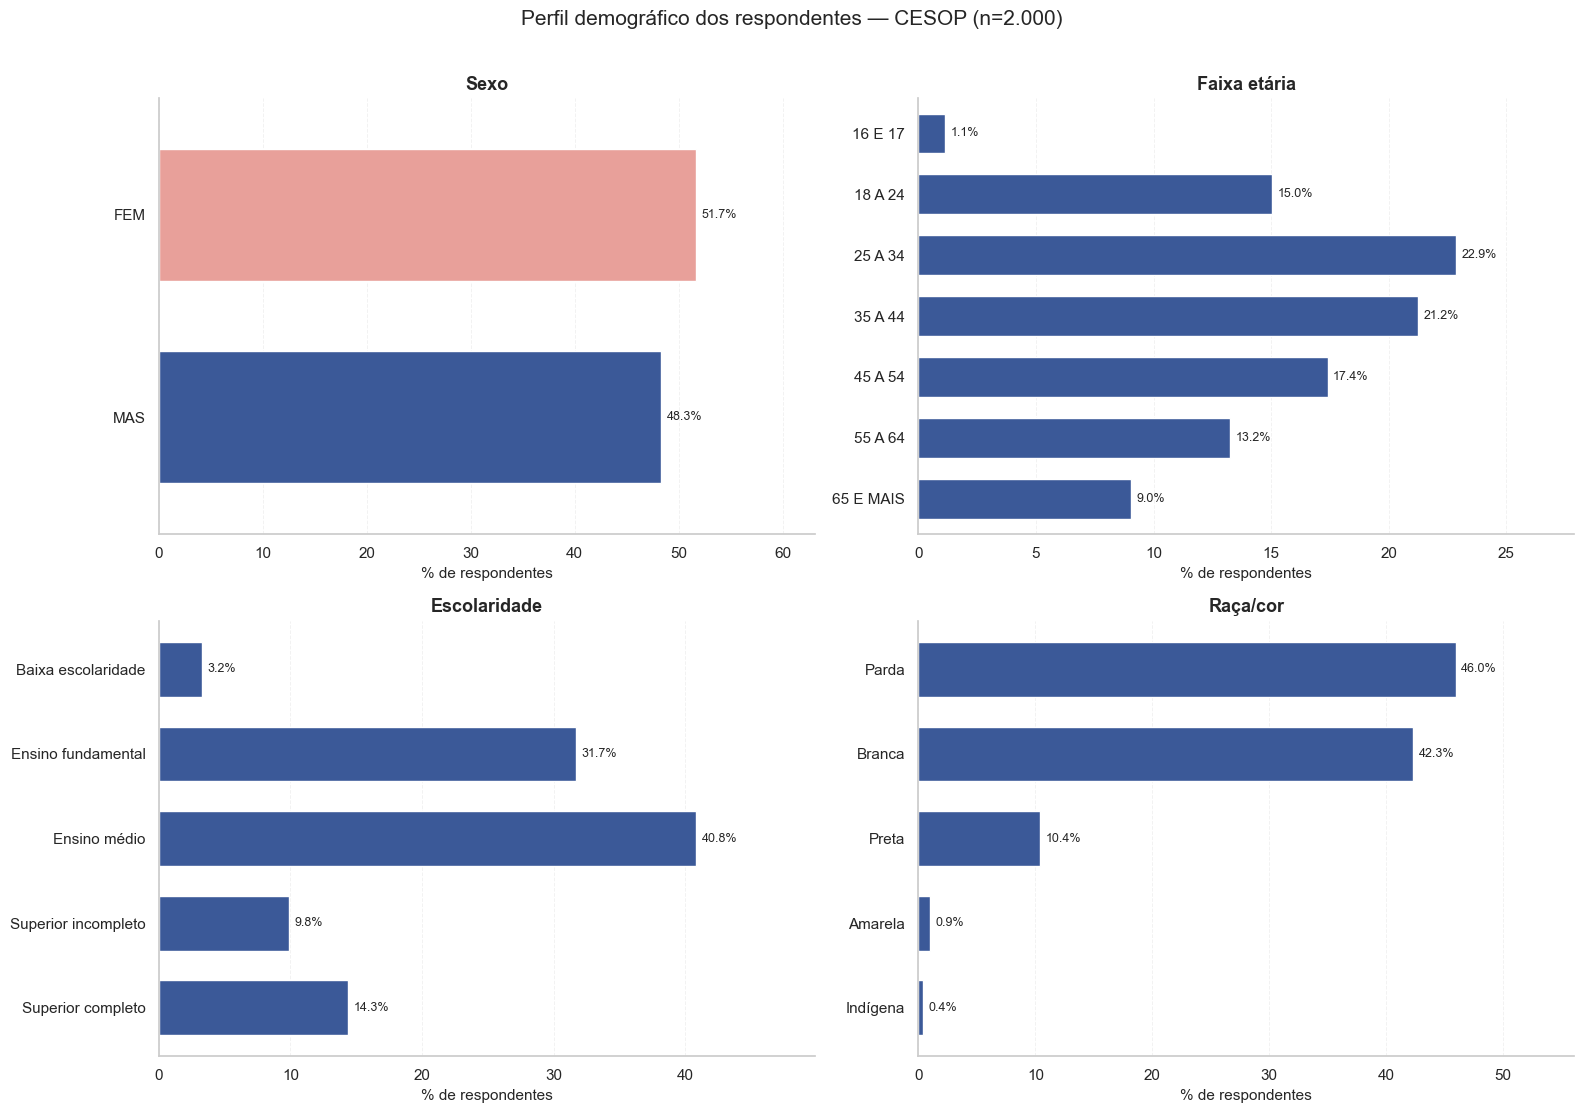

In [130]:
# Helper reutilizado pelas três figuras do perfil sociodemográfico.
# ordered_index define a ordem de cima para baixo; color_map permite cor por categoria.
def _barh_pct(series, ax, color, title, ordered_index=None, color_map=None, xlim=None):
    """Plota barras horizontais em % com rótulos e estilo limpo."""
    pct = series.value_counts(normalize=True) * 100
    if ordered_index is not None:
        pct = pct.reindex(ordered_index).dropna()
        invert = True   # primeira categoria no topo
    else:
        pct = pct.sort_values()
        invert = False  # maior frequência no topo

    cores = [color_map.get(str(c), color) for c in pct.index] if color_map else color

    pct.plot.barh(ax=ax, color=cores, width=0.65, edgecolor="white")
    if invert:
        ax.invert_yaxis()

    ax.set_title(title)
    ax.set_xlabel("% de respondentes")
    ax.set_ylabel("")
    ax.set_xlim(xlim if xlim else (0, min(100, pct.max() * 1.22)))
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", alpha=0.25, linestyle="--", linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=4, fontsize=9)

    
# Ordens semânticas explícitas para cada variável.
ORDEM_FX_ID = ["16 E 17", "18 A 24", "25 A 34", "35 A 44", "45 A 54", "55 A 64", "65 E MAIS"]

ORDEM_ESCOL=['Baixa escolaridade', 'Ensino fundamental', 'Ensino médio', 'Superior incompleto', 'Superior completo' ]

ORDEM_RENDA=['Sem rendimento', 'Até 1 SM', '1 a 5 SM', 'Acima de 5 SM', 'Acima de 20 SM']

# Rosa para feminino, azul para masculino.
CORES_SEXO = {
    "MAS": COR_PRINCIPAL,
    "FEM": COR_SECUNDARIA,
}


# ── Figura 1: Perfil demográfico ──────────────────────────────────────────────
fig1, axes1 = plt.subplots(2, 2, figsize=(16, 11))
fig1.suptitle("Perfil demográfico dos respondentes — CESOP (n=2.000)", fontsize=15, y=1.01)

_barh_pct(df_cesop["SEXO"], axes1[0, 0], COR_PRINCIPAL, "Sexo", color_map=CORES_SEXO)

_barh_pct(df_cesop["FX_ID"], axes1[0, 1], COR_PRINCIPAL, "Faixa etária",
          ordered_index=ORDEM_FX_ID)

_barh_pct(df_cesop["ESCOL_GRUPO"], axes1[1, 0], COR_PRINCIPAL, "Escolaridade",
          ordered_index=ORDEM_ESCOL)

_barh_pct(df_cesop["RACA"], axes1[1, 1], COR_PRINCIPAL, "Raça/cor")

# _barh_pct(df_cesop["RENDA_PESSOAL"], axes1[2, 0], COR_PRINCIPAL, "Renda Pessoal (Salários Mínimos)",
#           ordered_index=ORDEM_RENDA)

# _barh_pct(df_cesop["RENDA_FAMILIAR"], axes1[2, 1], COR_PRINCIPAL, "Renda Familiar (Salários Mínimos)",
#           ordered_index=ORDEM_RENDA)

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "01a_perfil_demografico.png", dpi=120, bbox_inches="tight")
plt.show()

**Perfil territorial**

Em seguida, observa-se a distribuição regional dos entrevistados, importante para contextualizar possíveis diferenças territoriais nas respostas.

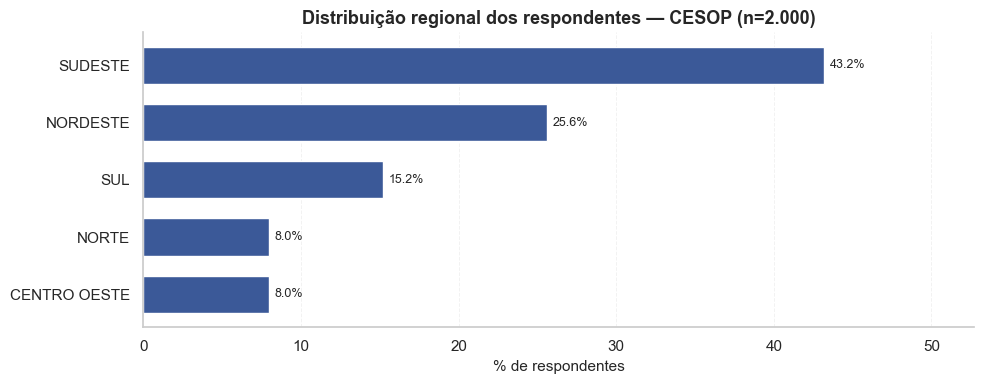

In [131]:
# ── Figura 2: Distribuição regional ───────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 4))

_barh_pct(df_cesop["REGIAO"], ax2, COR_PRINCIPAL,
          "Distribuição regional dos respondentes — CESOP (n=2.000)")

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "01b_perfil_territorial.png", dpi=120, bbox_inches="tight")
plt.show()

**Perfil socioeconômico**

Por fim, as variáveis de renda pessoal e familiar permitem caracterizar a condição econômica individual e domiciliar dos respondentes.

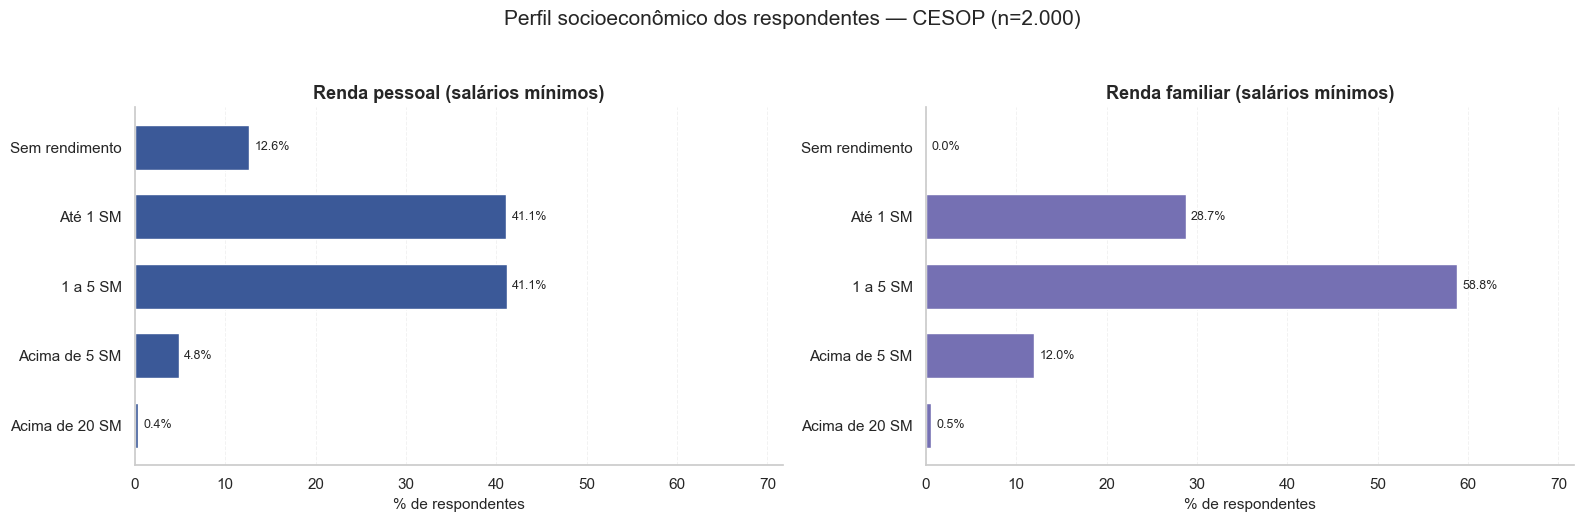

In [132]:
# ── Figura 3: Perfil socioeconômico ───────────────────────────────────────────
# Escala X compartilhada entre renda pessoal e familiar para comparação justa.
max_x_renda = max(
    (df_cesop["RENDA_PESSOAL"].value_counts(normalize=True) * 100).max(),
    (df_cesop["RENDA_FAMILIAR"].value_counts(normalize=True) * 100).max(),
)
xlim_renda = (0, min(100, max_x_renda * 1.22))

fig3, axes3 = plt.subplots(1, 2, figsize=(16, 5))
fig3.suptitle("Perfil socioeconômico dos respondentes — CESOP (n=2.000)", fontsize=15, y=1.04)

_barh_pct(df_cesop["RENDA_PESSOAL"], axes3[0], COR_PRINCIPAL,
          "Renda pessoal (salários mínimos)", ordered_index=ORDEM_RENDA, xlim=xlim_renda)
_barh_pct(df_cesop["RENDA_FAMILIAR"], axes3[1], "#7570b3",
          "Renda familiar (salários mínimos)", ordered_index=ORDEM_RENDA, xlim=xlim_renda)

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "01c_perfil_socioeconomico.png", dpi=120, bbox_inches="tight")
plt.show()

## 2. Lembrança do voto em 2022

Comparamos quanto os respondentes se lembram do voto para os três cargos perguntados (deputado estadual, federal e senador), e como a lembrança varia por escolaridade e idade.


Analise Geral

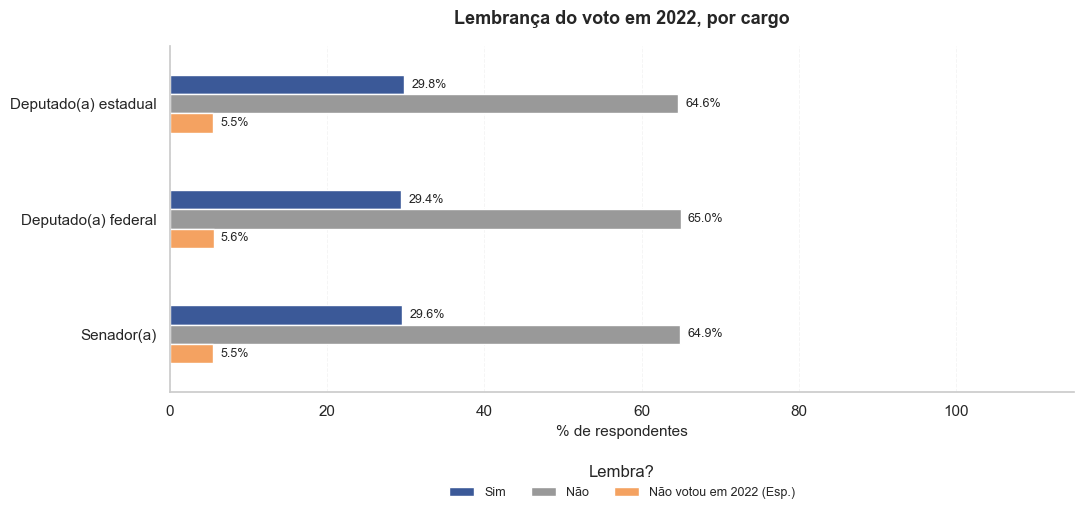

In [133]:
# === Constantes e helpers compartilhados pelos três gráficos de lembrança de voto ===

COR_SIM       = COR_PRINCIPAL   # azul
COR_NAO       = "#999999"        # cinza médio
COR_NAO_VOTOU = "#f4a261"        # laranja suave

PALETA_LEMBRANCA   = {"Sim": COR_SIM, "Não": COR_NAO, "Não votou": COR_NAO_VOTOU}
CORES_TEXTO_LEMB   = {"Sim": "white", "Não": "white", "Não votou": "#333333"}
ORDEM_LEMBRANCA    = ["Sim", "Não", "Não votou"]

ORDEM_CARGOS_LEMB = ["Deputado(a) estadual", "Deputado(a) federal", "Senador(a)"]
ORDEM_FX_LEMB     = ["16 E 17", "18 A 24", "25 A 34", "35 A 44",
                      "45 A 54", "55 A 64", "65 E MAIS"]
ORDEM_ESCOL_LEMB  = ['Baixa escolaridade', 'Ensino fundamental', 'Ensino médio', 'Superior incompleto', 'Superior completo' ]
LIMIAR_ROTULO_LEMB = 5.0  # segmentos < 5% não recebem rótulo


def _cols_lemb(df):
    """Reordena colunas: Sim → Não → Não votou → extras. Retorna df e lista de colunas."""
    fixas  = [c for c in ORDEM_LEMBRANCA if c in df.columns]
    extras = [c for c in df.columns if c not in ORDEM_LEMBRANCA]
    cols   = fixas + extras
    return df[cols], cols


def _rotulos_empilhados(ax, colunas, fmt="%.0f%%", limiar=LIMIAR_ROTULO_LEMB):
    """Rótulos de % no centro de cada segmento; omite segmentos abaixo do limiar."""
    for i, container in enumerate(ax.containers):
        cat = colunas[i]
        cor_txt = CORES_TEXTO_LEMB.get(str(cat), "white")
        for bar in container:
            val = bar.get_width()
            if pd.isna(val) or val < limiar:
                continue
            x = bar.get_x() + val / 2
            y = bar.get_y() + bar.get_height() / 2
            ax.text(x, y, fmt % val, ha="center", va="center",
                    fontsize=9, color=cor_txt, fontweight="bold")


def _estilo_lemb(ax, title, xlabel, xlim=(0, 100)):
    """Aplica estilo padrão compartilhado pelos três gráficos."""
    ax.set_title(title, pad=16)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("")
    ax.set_xlim(xlim)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def _legenda_lemb(ax, colunas):
    """Legenda padronizada abaixo do gráfico, horizontal, sem borda."""
    ax.legend(
        title="Lembra?", loc="upper center", bbox_to_anchor=(0.5, -0.18),
        ncol=len(colunas), frameon=False, fontsize=9,
    )


# === Gráfico 1: Lembrança por cargo ===
cargos_map = {
    "P_01A": "Deputado(a) estadual",
    "P_01B": "Deputado(a) federal",
    "P_01C": "Senador(a)",
}

df_lembranca_raw = pd.DataFrame({
    label: df_cesop[col].value_counts(normalize=True) * 100
    for col, label in cargos_map.items()
}).T.fillna(0)

df_lembranca, colunas_cargo = _cols_lemb(df_lembranca_raw)
df_lembranca = df_lembranca.reindex(
    [c for c in ORDEM_CARGOS_LEMB if c in df_lembranca.index]
)
cores_cargo = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_cargo]

fig, ax = plt.subplots(figsize=(11, 5))
df_lembranca[colunas_cargo].plot.barh(ax=ax, color=cores_cargo, width=0.5)
ax.invert_yaxis()
_estilo_lemb(ax, "Lembrança do voto em 2022, por cargo", "% de respondentes", xlim=(0, 115))

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=5, fontsize=9)

_legenda_lemb(ax, colunas_cargo)
plt.tight_layout()
fig.subplots_adjust(bottom=0.2)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_por_cargo.png", dpi=120, bbox_inches="tight")
plt.show()

# print("Categorias encontradas:", colunas_cargo)

Analise deputado estadual

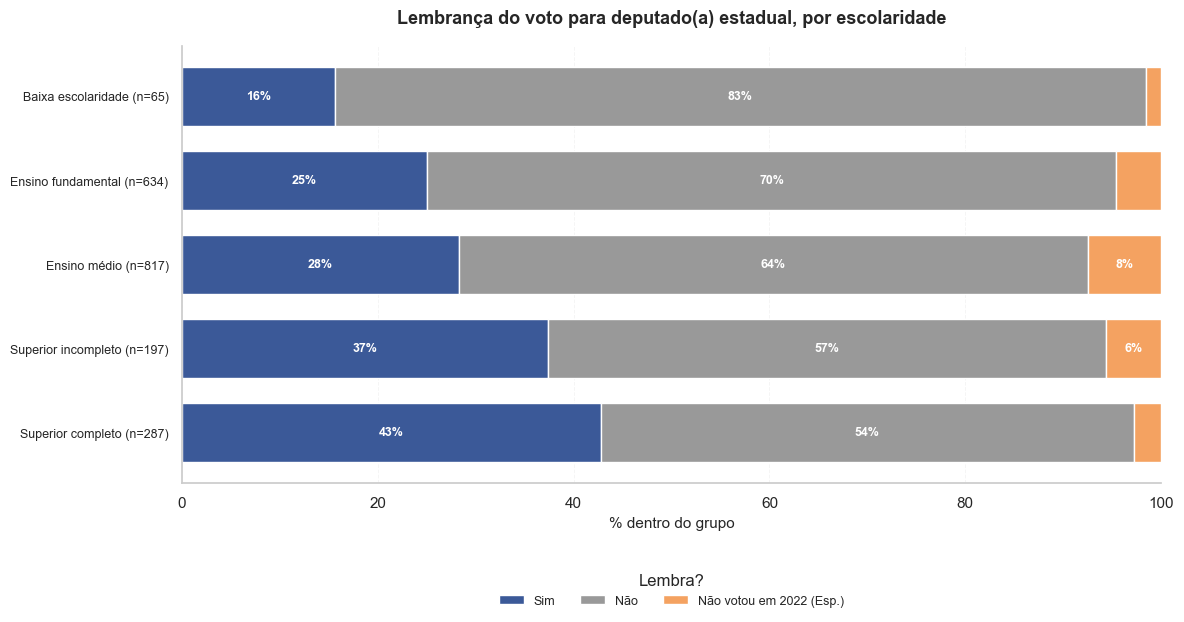

In [134]:
# n= calculado antes de crosstab para refletir o total de respondentes por grupo.
counts_escol = df_cesop["ESCOL_GRUPO"].value_counts()

ct_escol_raw = pd.crosstab(df_cesop["ESCOL_GRUPO"], df_cesop["P_01A"], normalize="index") * 100
ct_escol, colunas_e = _cols_lemb(ct_escol_raw)
ct_escol = ct_escol.reindex([c for c in ORDEM_ESCOL_LEMB if c in ct_escol.index])

cores_e = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_e]

labels_y_escol = [
    f"{cat} (n={int(counts_escol.get(cat, 0)):,})"
    for cat in ct_escol.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_escol[colunas_e].plot.barh(stacked=True, ax=ax, color=cores_e, width=0.7)

# Define ticks explicitamente antes de invert para garantir correspondência correta.
ax.set_yticks(range(len(ct_escol.index)))
ax.set_yticklabels(labels_y_escol, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por escolaridade",
             "% dentro do grupo")
_rotulos_empilhados(ax, colunas_e)
_legenda_lemb(ax, colunas_e)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_escolaridade.png", dpi=120, bbox_inches="tight")
plt.show()

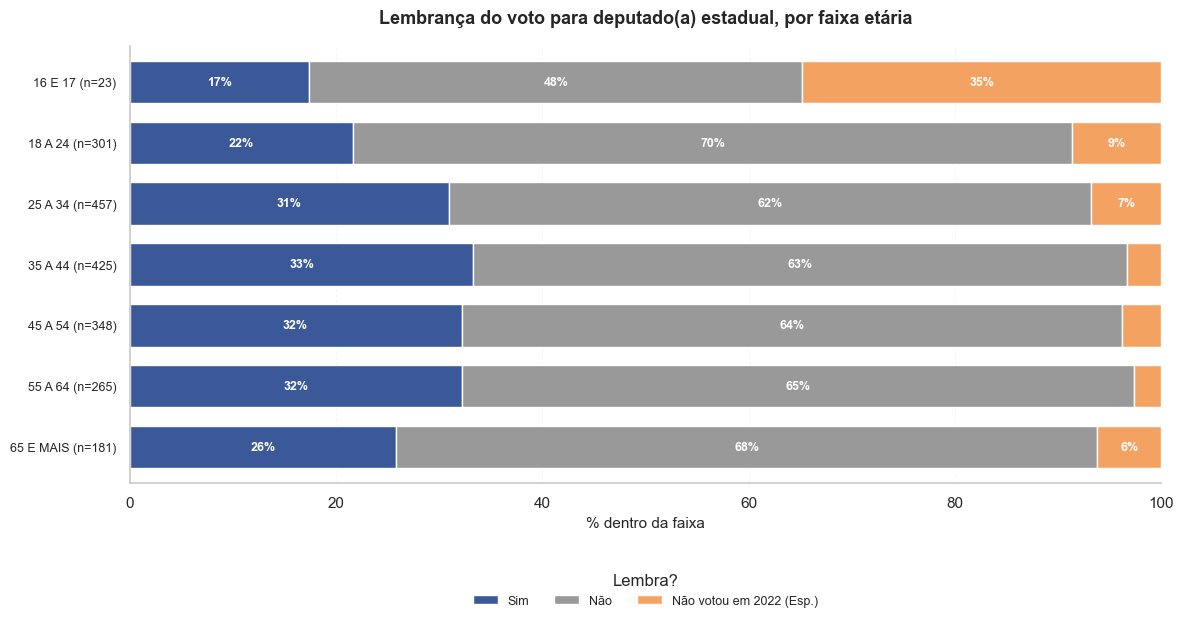

In [135]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["FX_ID"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["FX_ID"], df_cesop["P_01A"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por faixa etária",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_fx_idade.png", dpi=120, bbox_inches="tight")
plt.show()

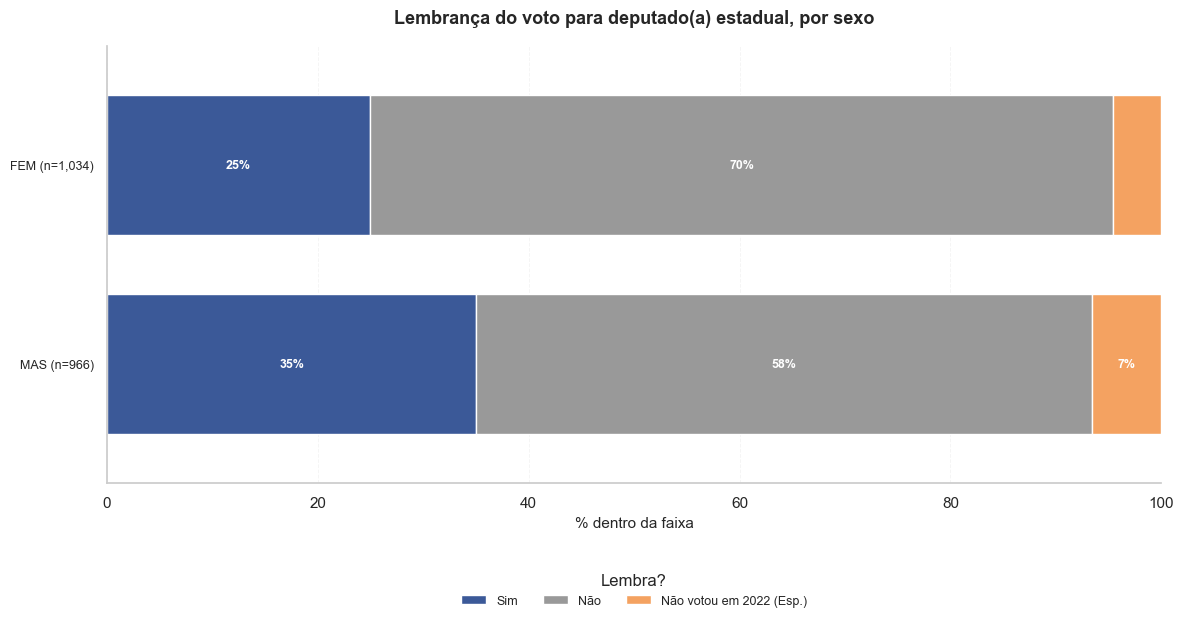

In [136]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["SEXO"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["SEXO"], df_cesop["P_01A"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por sexo",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_sexo.png", dpi=120, bbox_inches="tight")
plt.show()

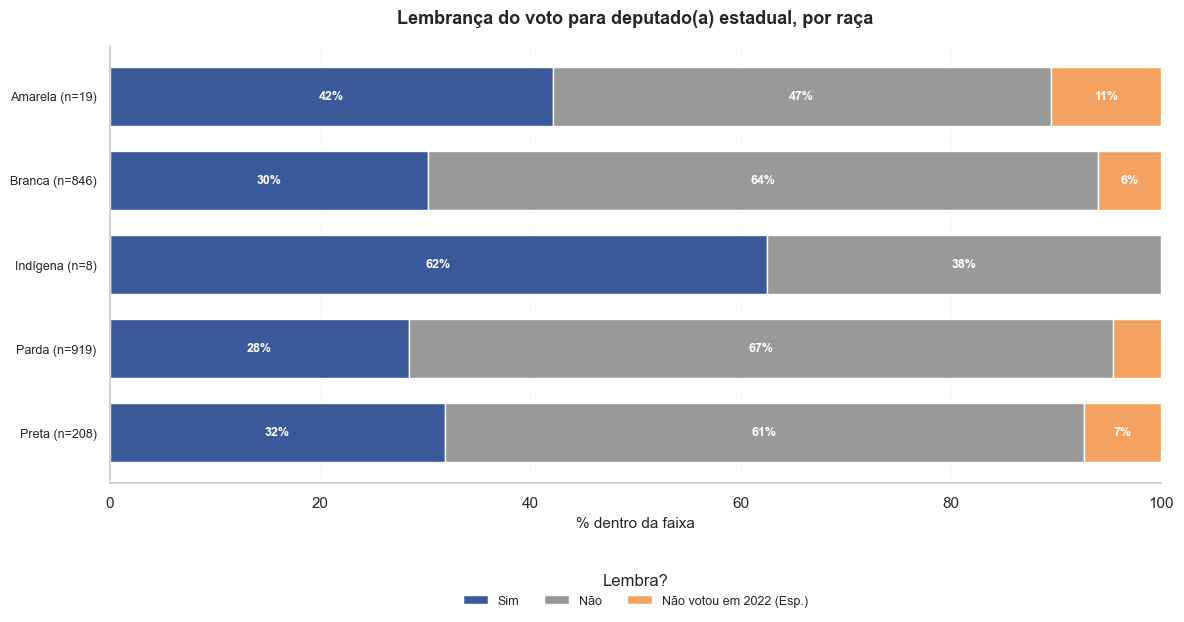

In [137]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["RACA"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RACA"], df_cesop["P_01A"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por raça",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_raca.png", dpi=120, bbox_inches="tight")
plt.show()

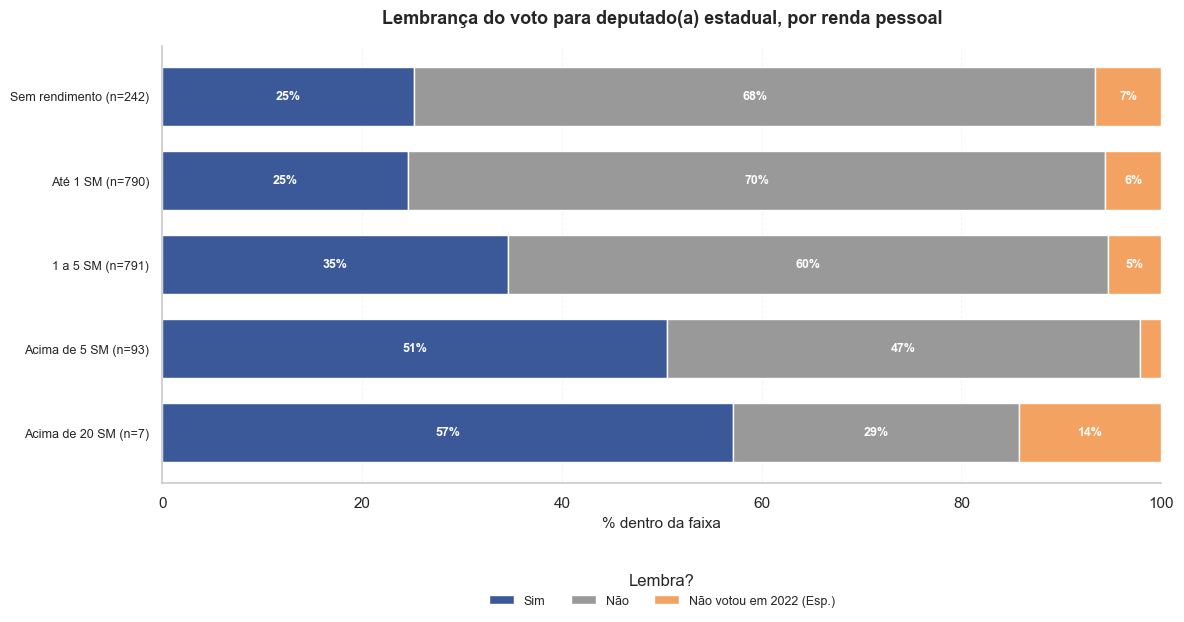

In [138]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["RENDA_PESSOAL"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RENDA_PESSOAL"], df_cesop["P_01A"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por renda pessoal",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_renda_pessoal.png", dpi=120, bbox_inches="tight")
plt.show()

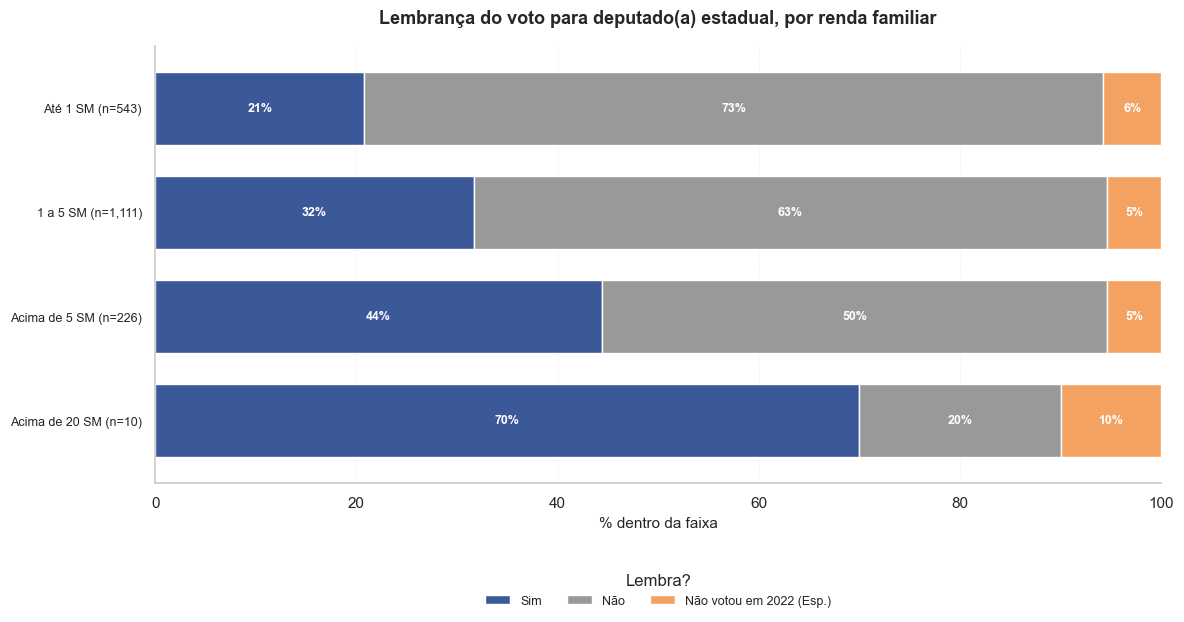

In [139]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["RENDA_FAMILIAR"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RENDA_FAMILIAR"], df_cesop["P_01A"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por renda familiar",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_renda_familiar.png", dpi=120, bbox_inches="tight")
plt.show()

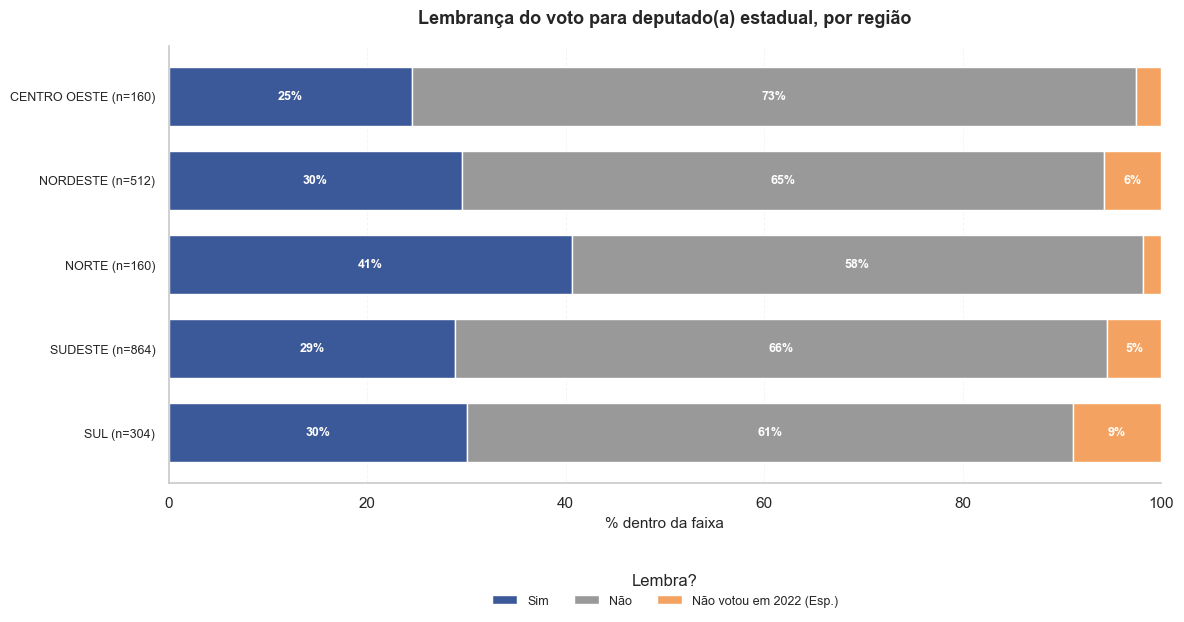

In [140]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["REGIAO"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["REGIAO"], df_cesop["P_01A"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) estadual, por região",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_estadual_região.png", dpi=120, bbox_inches="tight")
plt.show()

Analise Deputado Federal

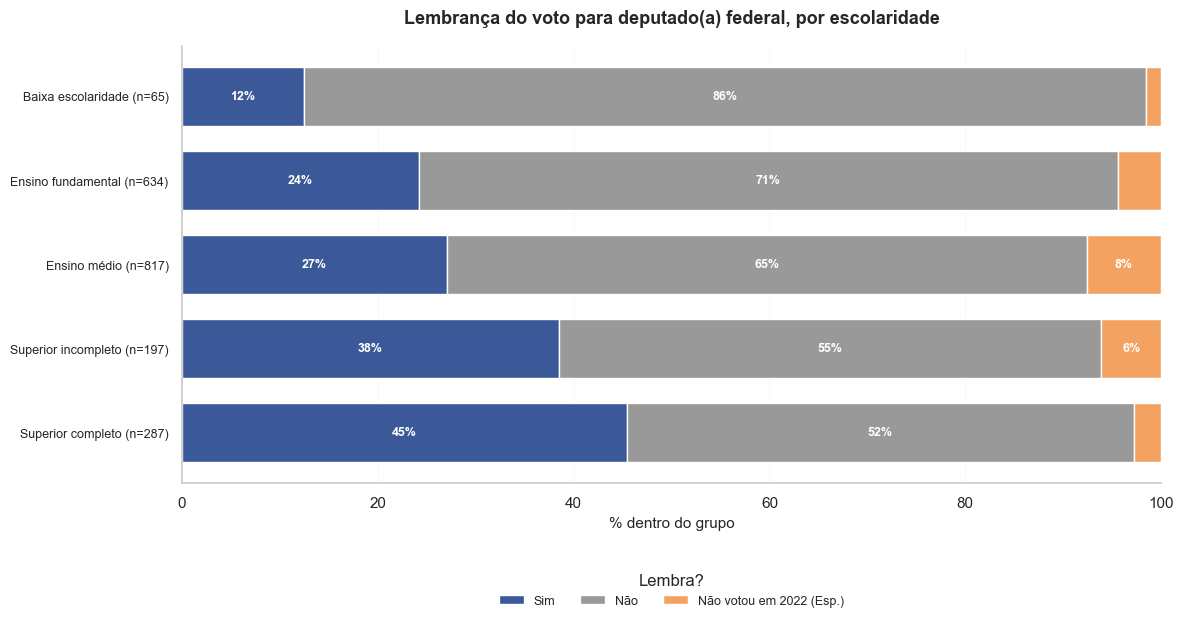

In [141]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["ESCOL_GRUPO"].value_counts()

ct_escol_raw = pd.crosstab(df_cesop["ESCOL_GRUPO"], df_cesop["P_01B"], normalize="index") * 100
ct_escol, colunas_e = _cols_lemb(ct_escol_raw)
ct_escol = ct_escol.reindex([c for c in ORDEM_ESCOL_LEMB if c in ct_escol.index])

cores_e = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_e]

labels_y_escol = [
    f"{cat} (n={int(counts_escol.get(cat, 0)):,})"
    for cat in ct_escol.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_escol[colunas_e].plot.barh(stacked=True, ax=ax, color=cores_e, width=0.7)

# Define ticks explicitamente antes de invert para garantir correspondência correta.
ax.set_yticks(range(len(ct_escol.index)))
ax.set_yticklabels(labels_y_escol, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por escolaridade",
             "% dentro do grupo")
_rotulos_empilhados(ax, colunas_e)
_legenda_lemb(ax, colunas_e)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_escolaridade.png", dpi=120, bbox_inches="tight")
plt.show()

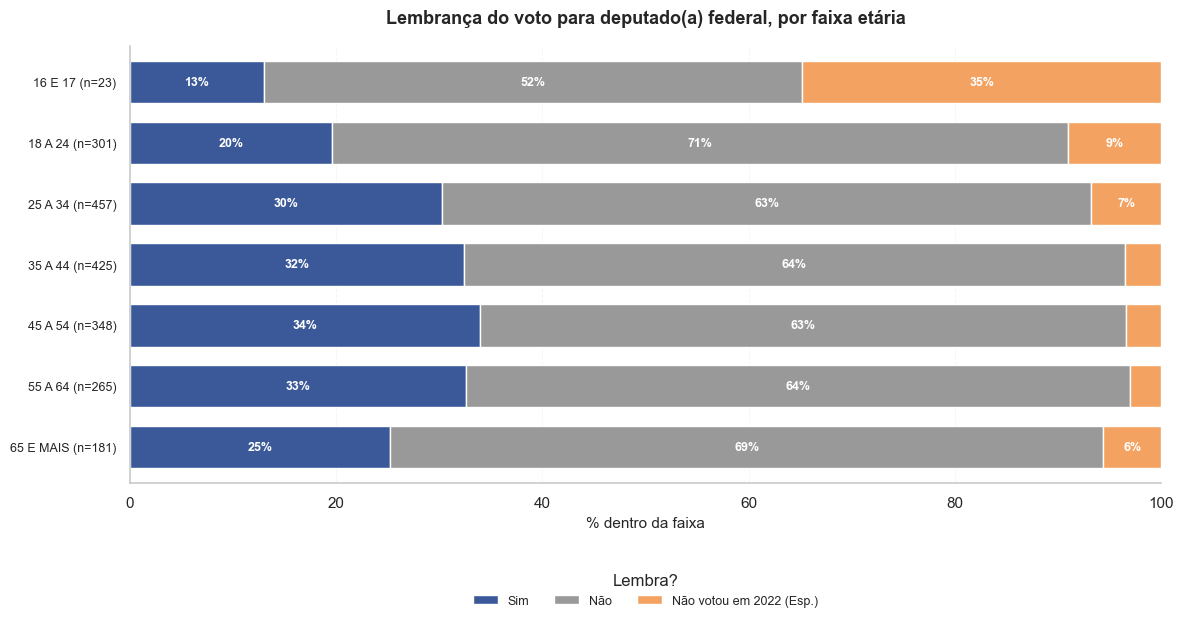

In [142]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["FX_ID"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["FX_ID"], df_cesop["P_01B"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por faixa etária",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_fx_idade.png", dpi=120, bbox_inches="tight")
plt.show()

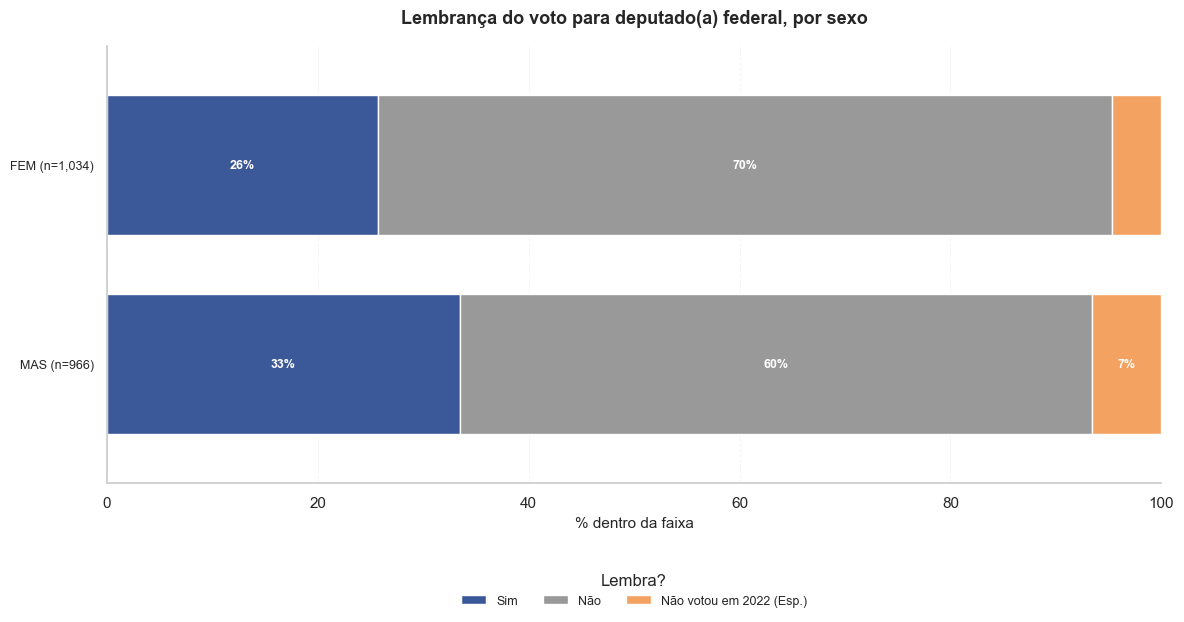

In [143]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["SEXO"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["SEXO"], df_cesop["P_01B"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por sexo",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_sexo.png", dpi=120, bbox_inches="tight")
plt.show()

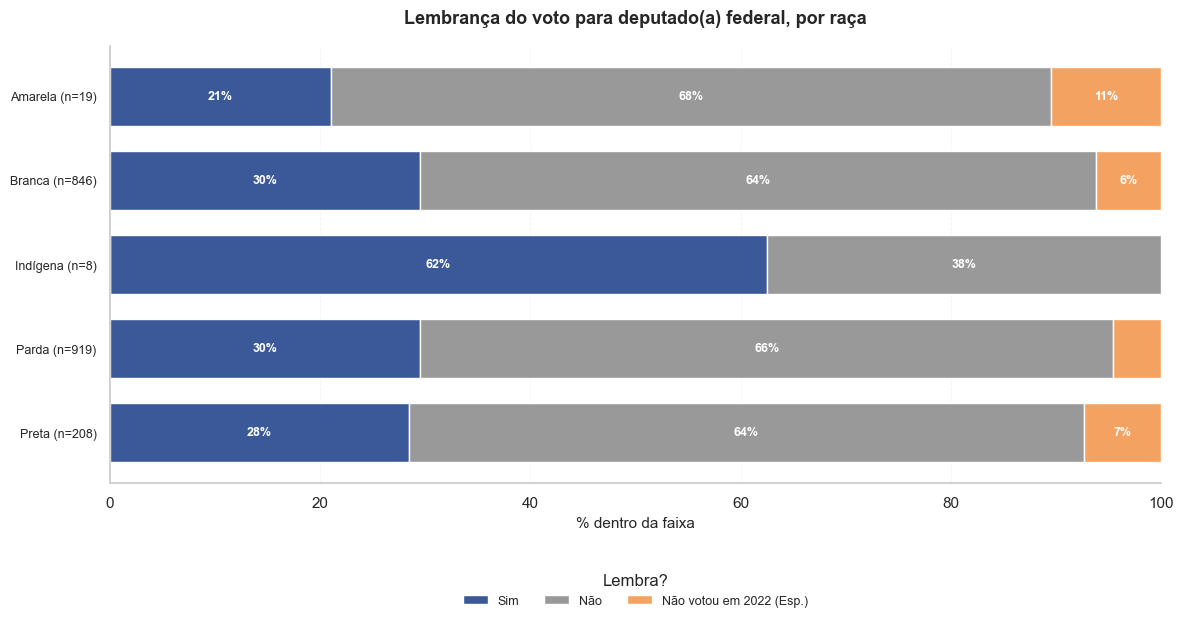

In [144]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["RACA"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RACA"], df_cesop["P_01B"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por raça",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_raca.png", dpi=120, bbox_inches="tight")
plt.show()

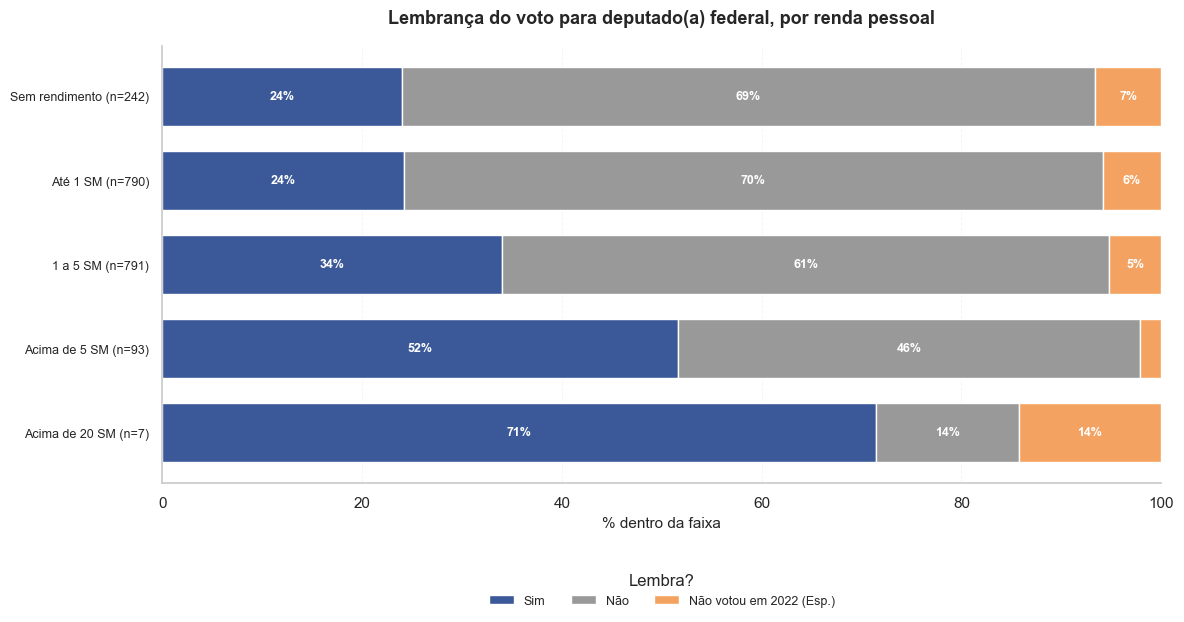

In [145]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["RENDA_PESSOAL"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RENDA_PESSOAL"], df_cesop["P_01B"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por renda pessoal",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_renda_pessoal.png", dpi=120, bbox_inches="tight")
plt.show()

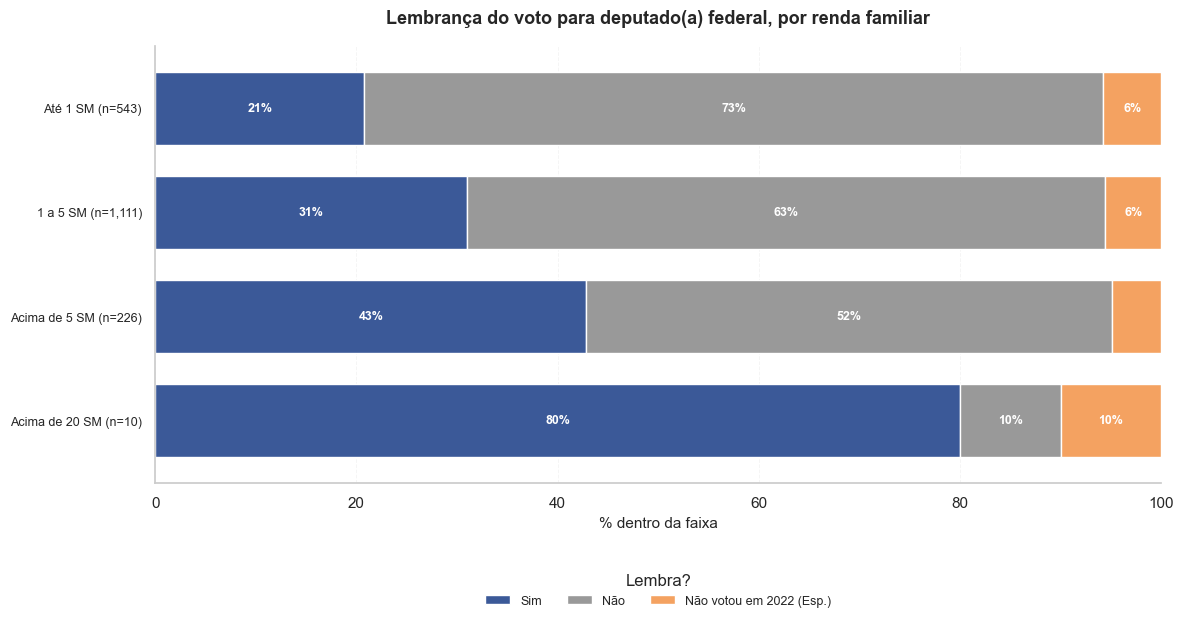

In [146]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["RENDA_FAMILIAR"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RENDA_FAMILIAR"], df_cesop["P_01B"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por renda familiar",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_renda_familiar.png", dpi=120, bbox_inches="tight")
plt.show()

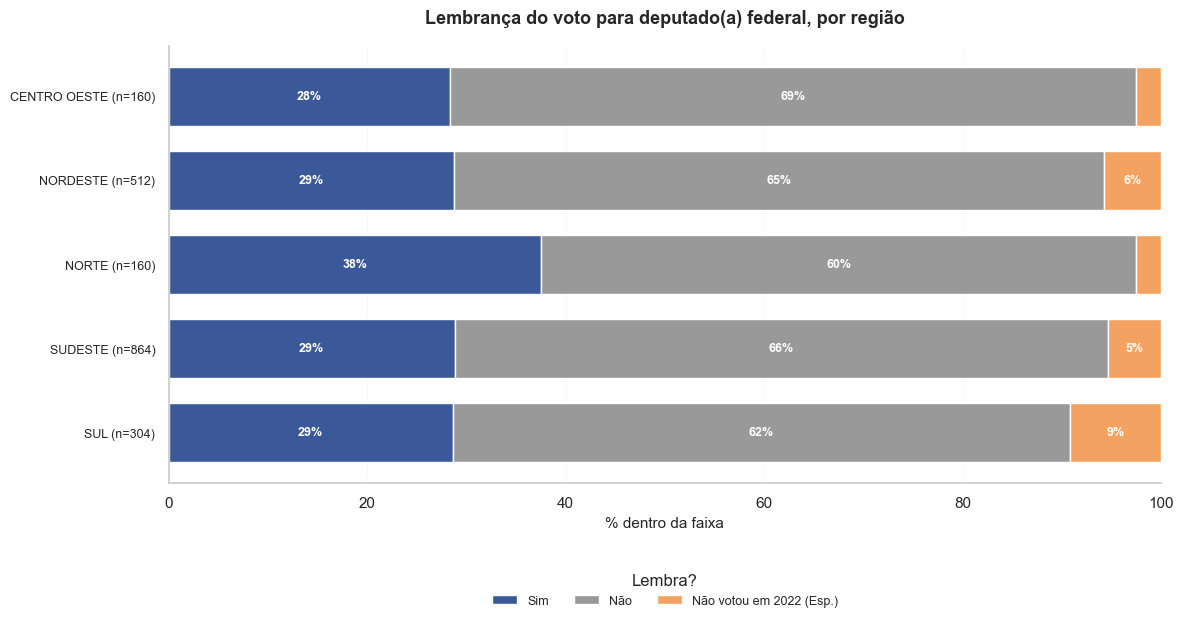

In [147]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["REGIAO"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["REGIAO"], df_cesop["P_01B"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para deputado(a) federal, por região",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_deputado_federal_região.png", dpi=120, bbox_inches="tight")
plt.show()

Analise Senador P_01C


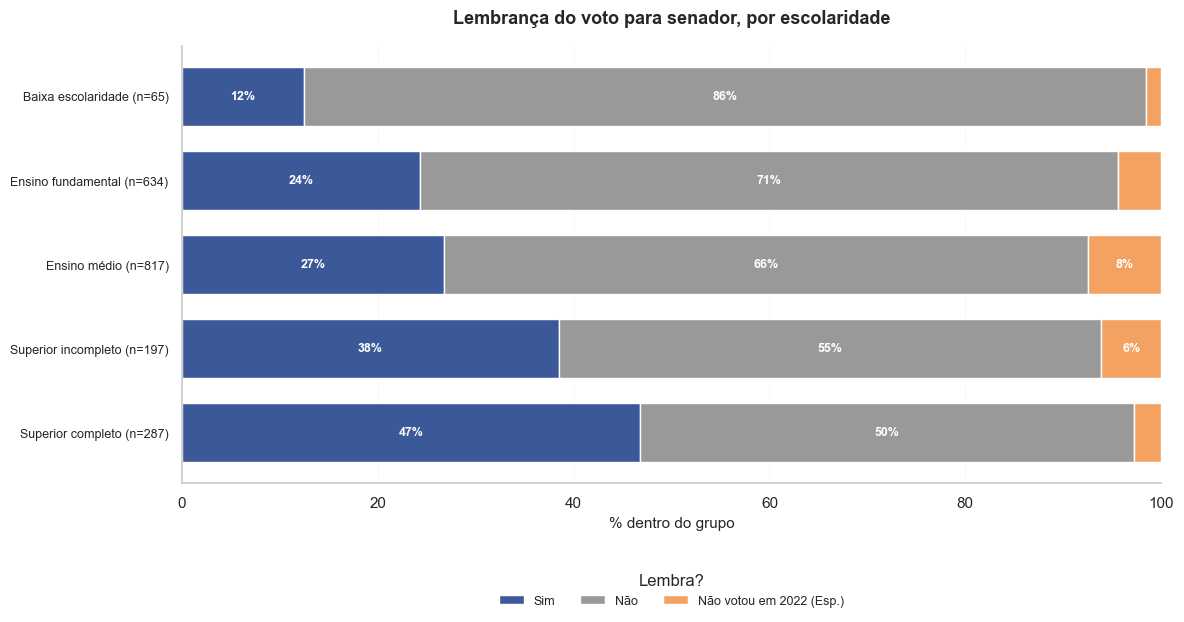

In [148]:
ct_escol_raw = pd.crosstab(df_cesop["ESCOL_GRUPO"], df_cesop["P_01C"], normalize="index") * 100
ct_escol, colunas_e = _cols_lemb(ct_escol_raw)
ct_escol = ct_escol.reindex([c for c in ORDEM_ESCOL_LEMB if c in ct_escol.index])

cores_e = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_e]

labels_y_escol = [
    f"{cat} (n={int(counts_escol.get(cat, 0)):,})"
    for cat in ct_escol.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_escol[colunas_e].plot.barh(stacked=True, ax=ax, color=cores_e, width=0.7)

# Define ticks explicitamente antes de invert para garantir correspondência correta.
ax.set_yticks(range(len(ct_escol.index)))
ax.set_yticklabels(labels_y_escol, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por escolaridade",
             "% dentro do grupo")
_rotulos_empilhados(ax, colunas_e)
_legenda_lemb(ax, colunas_e)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02f_lembranca_voto_senador_escolaridade.png", dpi=120, bbox_inches="tight")
plt.show()

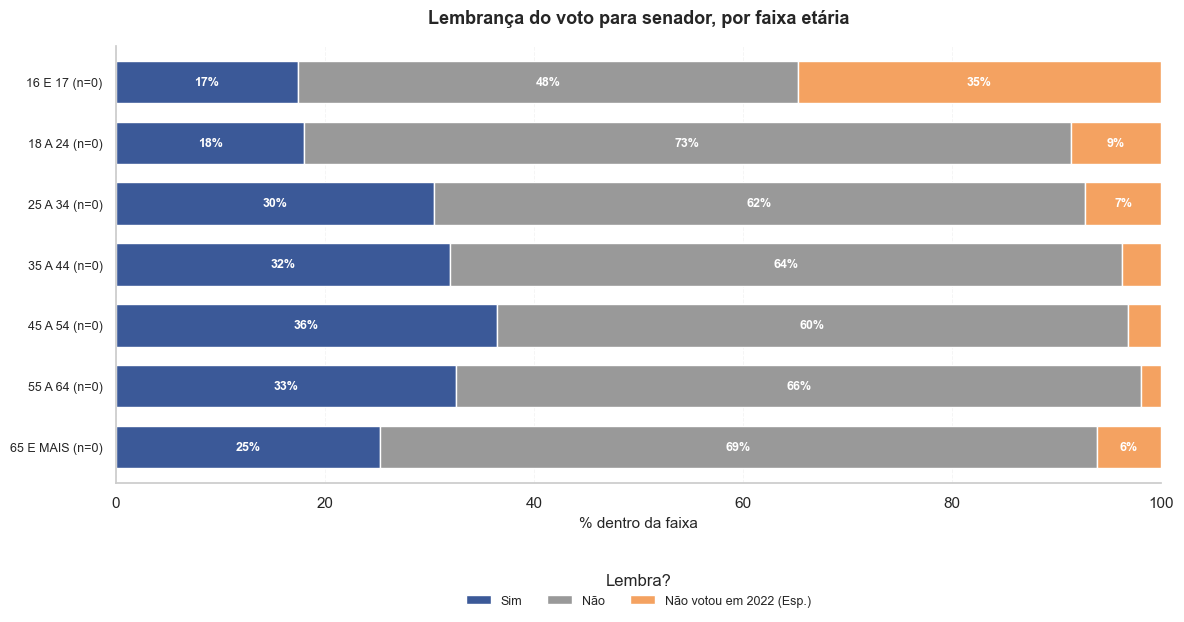

In [149]:
ct_fx_raw = pd.crosstab(df_cesop["FX_ID"], df_cesop["P_01C"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por faixa etária",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02g_lembranca_voto_senador_fx_idade.png", dpi=120, bbox_inches="tight")
plt.show()

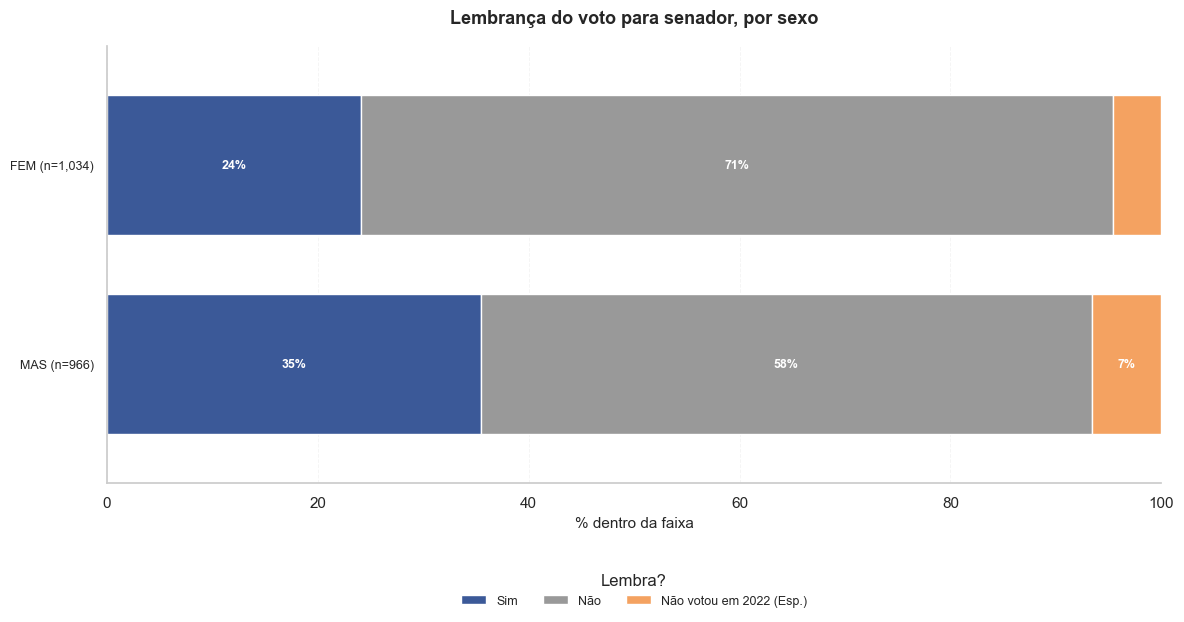

In [150]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["SEXO"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["SEXO"], df_cesop["P_01C"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por sexo",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_senador_sexo.png", dpi=120, bbox_inches="tight")
plt.show()

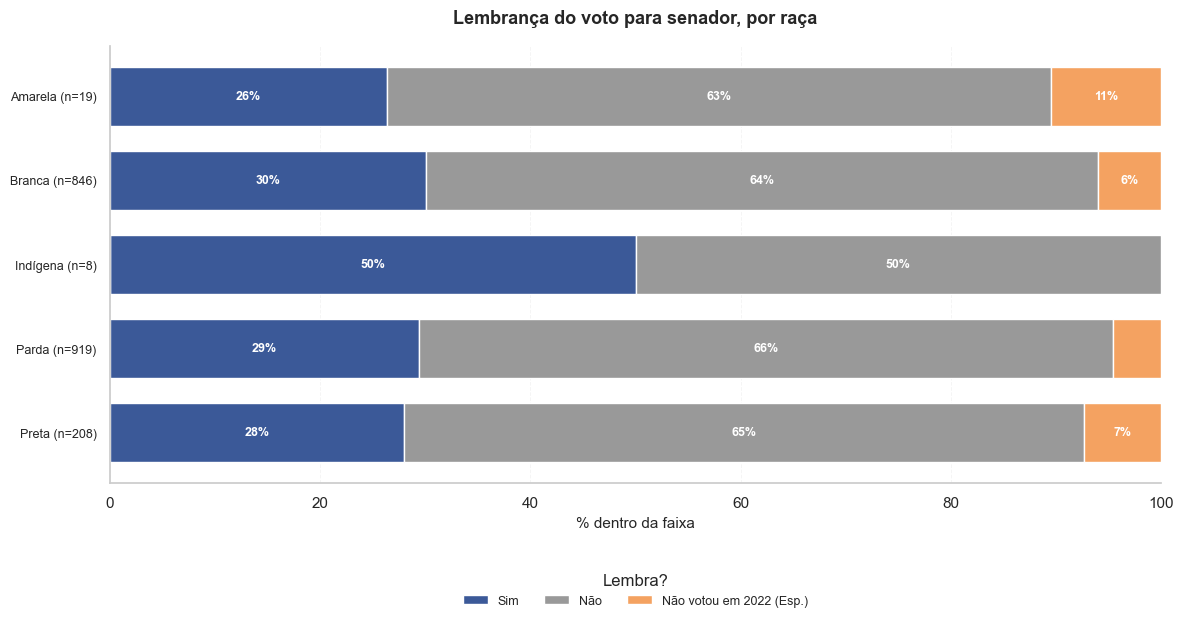

In [151]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["RACA"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RACA"], df_cesop["P_01C"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por raça",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_senador_raca.png", dpi=120, bbox_inches="tight")
plt.show()

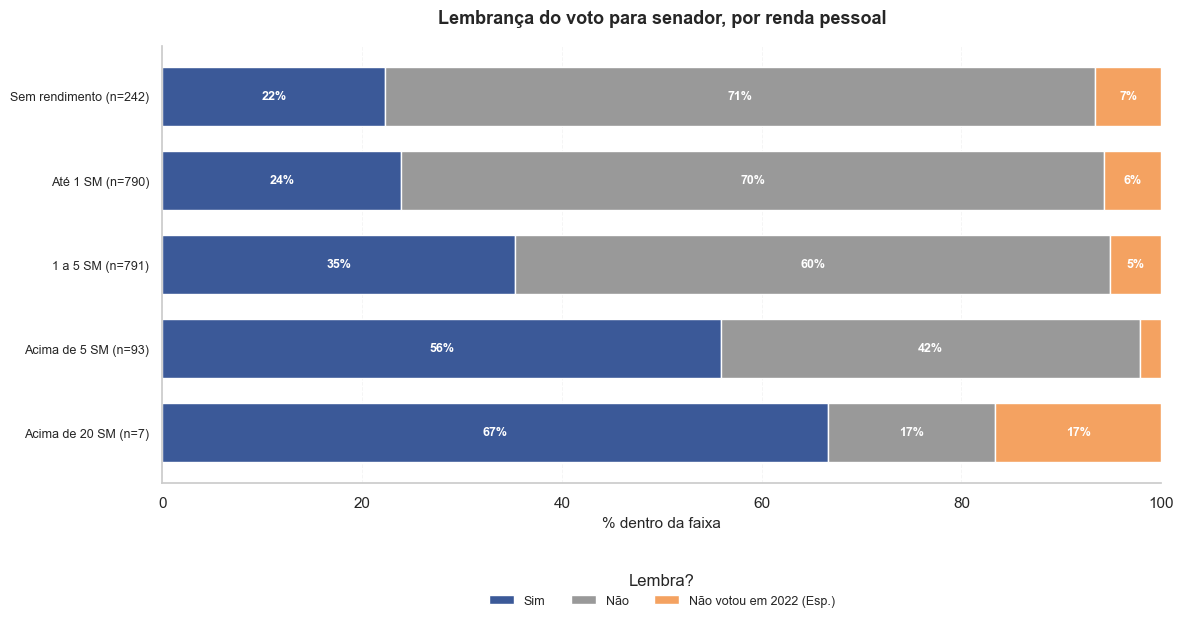

In [152]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["RENDA_PESSOAL"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RENDA_PESSOAL"], df_cesop["P_01C"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por renda pessoal",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_senador_renda_pessoal.png", dpi=120, bbox_inches="tight")
plt.show()

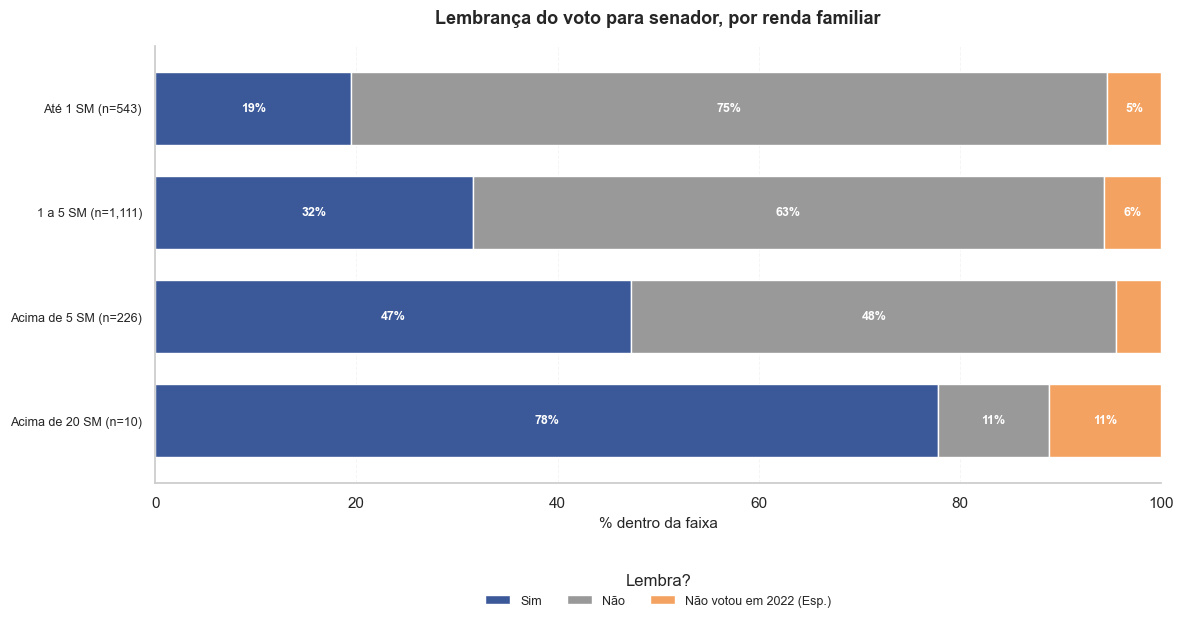

In [153]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["RENDA_FAMILIAR"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["RENDA_FAMILIAR"], df_cesop["P_01C"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por renda familiar",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_senador_renda_familiar.png", dpi=120, bbox_inches="tight")
plt.show()

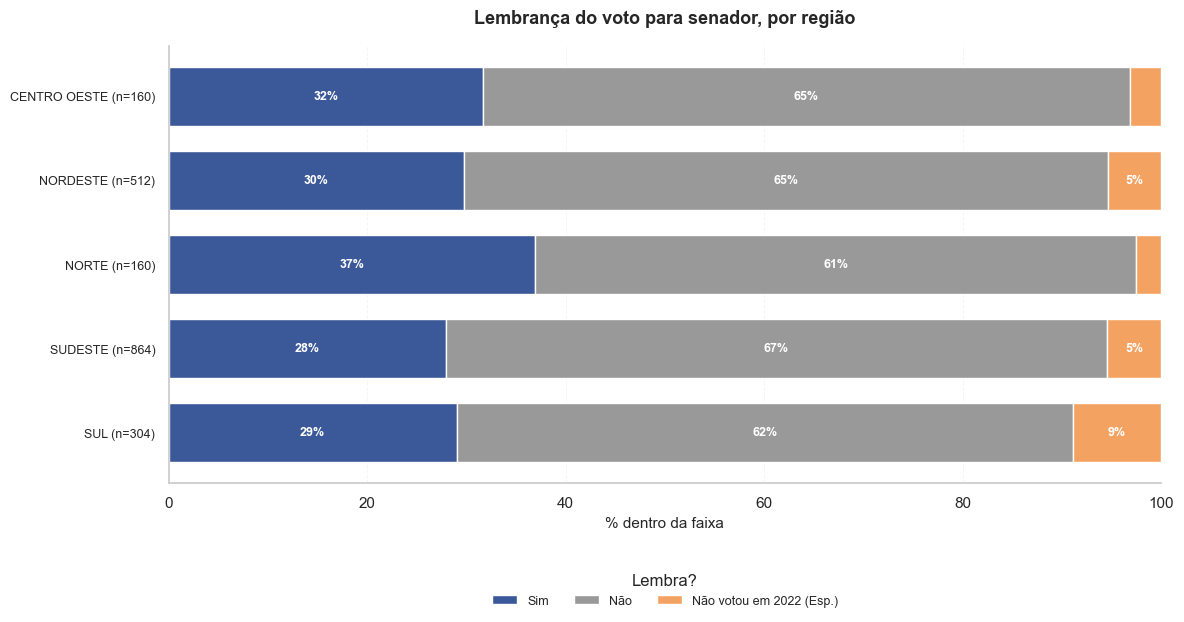

In [154]:
# Lembrança × faixa etária — barras empilhadas horizontais 100%.
counts_fx = df_cesop["REGIAO"].value_counts()

ct_fx_raw = pd.crosstab(df_cesop["REGIAO"], df_cesop["P_01C"], normalize="index") * 100
ct_fx, colunas_fx = _cols_lemb(ct_fx_raw)
# ct_fx = ct_fx.reindex([c for c in ORDEM_FX_LEMB if c in ct_fx.index])

cores_fx = [PALETA_LEMBRANCA.get(c, COR_NAO_VOTOU) for c in colunas_fx]

labels_y_fx = [
    f"{cat} (n={int(counts_fx.get(cat, 0)):,})"
    for cat in ct_fx.index
]

fig, ax = plt.subplots(figsize=(12, 6))

ct_fx[colunas_fx].plot.barh(stacked=True, ax=ax, color=cores_fx, width=0.7)

ax.set_yticks(range(len(ct_fx.index)))
ax.set_yticklabels(labels_y_fx, fontsize=9)
ax.invert_yaxis()

_estilo_lemb(ax, "Lembrança do voto para senador, por região",
             "% dentro da faixa")
_rotulos_empilhados(ax, colunas_fx)
_legenda_lemb(ax, colunas_fx)

plt.tight_layout()
fig.subplots_adjust(bottom=0.18)
plt.savefig(PATH_FIGURAS / "02_lembranca_voto_senador_região.png", dpi=120, bbox_inches="tight")
plt.show()

## 3. Prioridades políticas

Quais temas os respondentes consideram prioritários para a atuação política? A análise é organizada em três perspectivas:

1. **Primeira escolha** — tema considerado mais importante por cada respondente.
2. **Até três escolhas** — temas mais recorrentes considerando todas as menções.
3. **Variação regional** — como as primeiras escolhas diferem entre as regiões do Brasil.

> Os rótulos das prioridades foram abreviados para melhorar a legibilidade dos gráficos.

In [155]:
counts_fx = df_cesop["P_02_1"].value_counts()
counts_fx

P_02_1
Melhorar a qualidade da saúde                                                    400
Incentivar a geração de empregos                                                 294
Reduzir as desigualdades sociais                                                 286
Reduzir a violência                                                              250
Combater o preconceito (racismo, homofobia, diferença de classe social, etc.)    233
Melhorar a qualidade da educação                                                 222
Preservar os valores ligados à família                                           103
Aumentar os impostos de grandes fortunas (ou dos mais ricos)                      45
Ampliar os espaços de participação política da população                          40
Defender a igualdade entre homens e mulheres                                      38
Ampliar o uso de energias renováveis                                              25
Combater as mudanças climáticas/desmatamento              

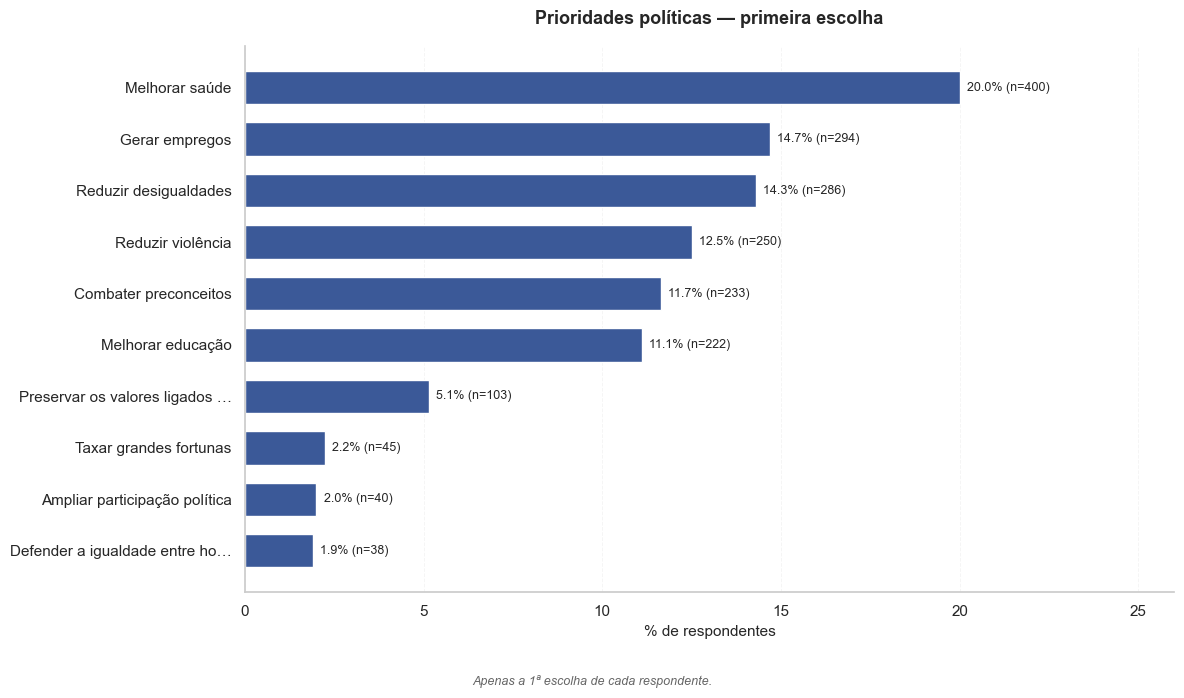

In [156]:
def _abrev_prio(nome):
    """Retorna versão abreviada da prioridade; fallback: trunca em 32 chars."""
    tabela = [
        ("preconceito",           "Combater preconceitos"),
        ("grandes fortunas",      "Taxar grandes fortunas"),
        ("impostos",              "Taxar grandes fortunas"),
        ("violência",             "Reduzir violência"),
        ("desigualdade",          "Reduzir desigualdades"),
        ("empregos",              "Gerar empregos"),
        ("saúde",                 "Melhorar saúde"),
        ("educação",              "Melhorar educação"),
        ("valores familiares",    "Preservar valores familiares"),
        ("participação política", "Ampliar participação política"),
        ("igualdade de gênero",   "Defender igualdade de gênero"),
        ("mudanças climáticas",   "Combater mudanças climáticas"),
        ("energia renovável",     "Incentivar energia renovável"),
    ]
    nome_lower = str(nome).lower()
    for chave, abrev in tabela:
        if chave in nome_lower:
            return abrev
    s = str(nome)
    return s if len(s) <= 32 else s[:29] + "…"


# === Gráfico 1: Primeira escolha ===
top1_raw = df_cesop["P_02_1"].value_counts().head(10)
df_top1 = pd.DataFrame({"pct": top1_raw / len(df_cesop) * 100, "n": top1_raw})
df_top1.index = [_abrev_prio(i) for i in df_top1.index]
df_top1 = df_top1.sort_values("pct")  # ascending → maior fica no topo com barh

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(df_top1.index, df_top1["pct"], color=COR_PRINCIPAL, height=0.65)

ax.set_title("Prioridades políticas — primeira escolha", pad=16)
ax.set_xlabel("% de respondentes")
ax.set_xlim(0, df_top1["pct"].max() * 1.30)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, pct, n in zip(bars, df_top1["pct"], df_top1["n"]):
    ax.text(pct + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=9)

fig.text(0.5, 0.01, "Apenas a 1ª escolha de cada respondente.",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(PATH_FIGURAS / "03_prioridade_politica_primeira_escolha.png", dpi=120, bbox_inches="tight")
plt.show()

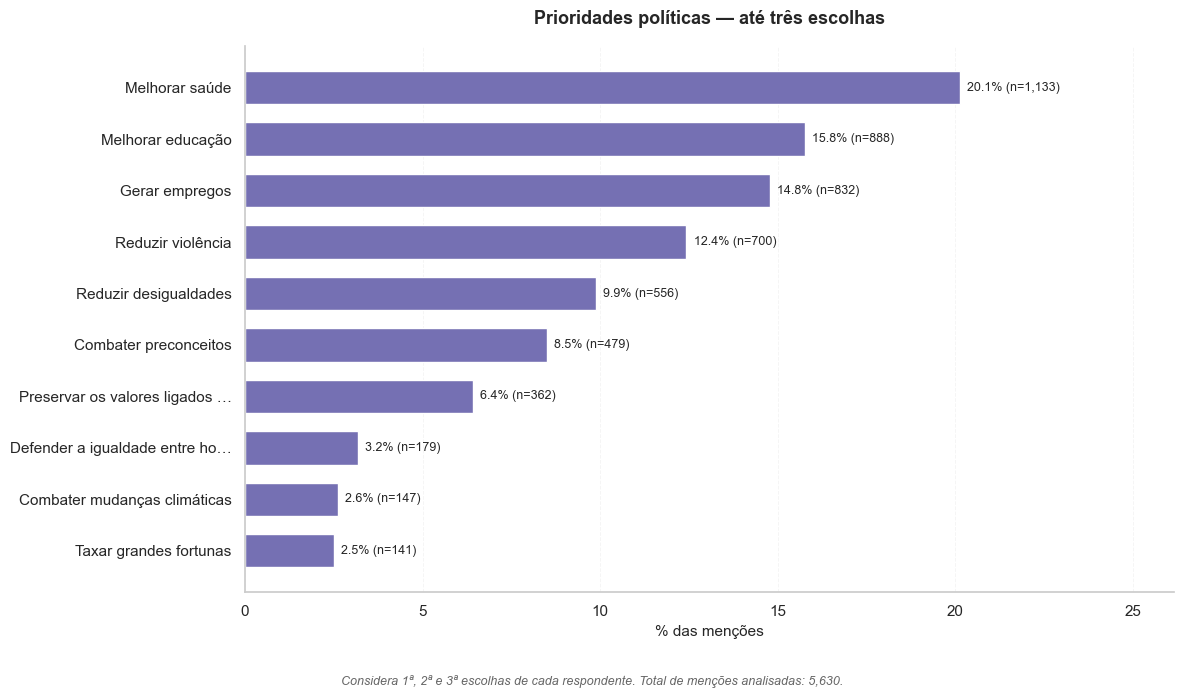

In [157]:
# === Gráfico 2: Até três escolhas ===
# Denominador = total de menções (não respondentes), pois cada respondente pode citar até 3.
cols_p2 = ["P_02_1", "P_02_2", "P_02_3"]
todas_prio = pd.concat([df_cesop[c] for c in cols_p2], ignore_index=True).dropna()
total_mencoes = len(todas_prio)

acum_raw = todas_prio.value_counts().head(10)
df_acum = pd.DataFrame({"pct": acum_raw / total_mencoes * 100, "n": acum_raw})
df_acum.index = [_abrev_prio(i) for i in df_acum.index]
df_acum = df_acum.sort_values("pct")  # maior fica no topo

COR_ACUM = "#7570b3"  # roxo — diferencia visualmente do gráfico de 1ª escolha

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(df_acum.index, df_acum["pct"], color=COR_ACUM, height=0.65)

ax.set_title("Prioridades políticas — até três escolhas", pad=16)
ax.set_xlabel("% das menções")
ax.set_xlim(0, df_acum["pct"].max() * 1.30)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, pct, n in zip(bars, df_acum["pct"], df_acum["n"]):
    ax.text(pct + 0.2, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=9)

fig.text(0.5, 0.01,
         f"Considera 1ª, 2ª e 3ª escolhas de cada respondente. "
         f"Total de menções analisadas: {total_mencoes:,}.",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(PATH_FIGURAS / "03_prioridade_politica_mais_escolhas.png", dpi=120, bbox_inches="tight")
plt.show()

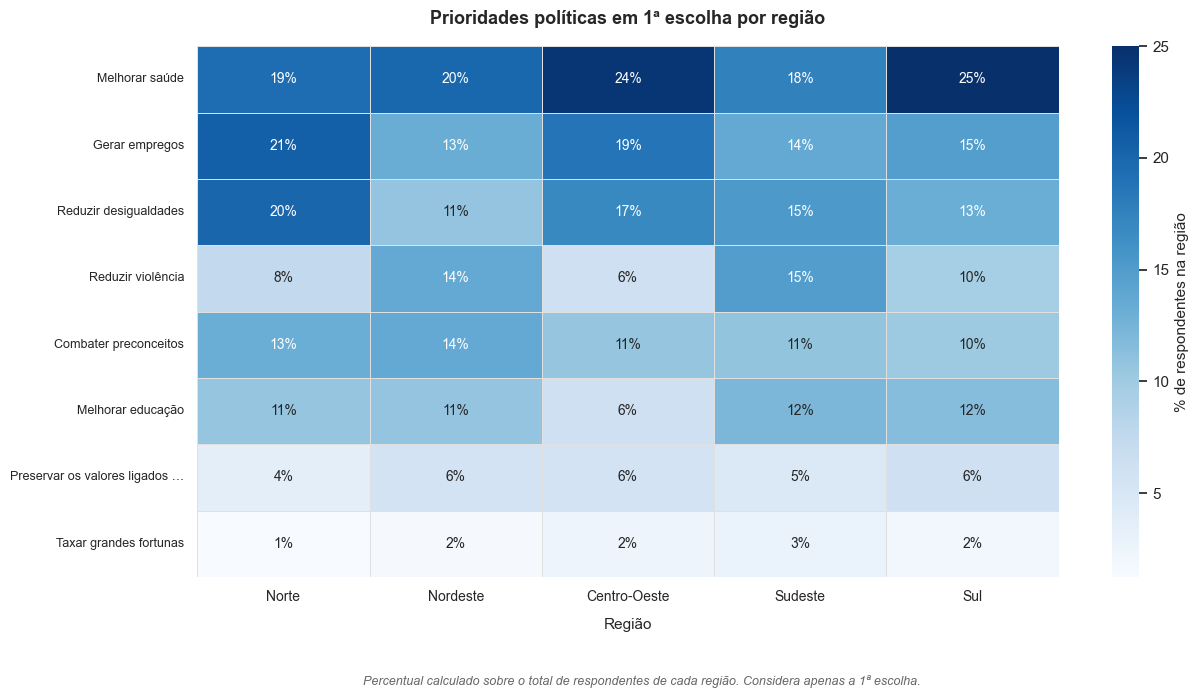

In [158]:
# === Gráfico 3: Heatmap — prioridades em 1ª escolha por região ===
# Denominador: total de respondentes de cada região (independente de responder P_02_1).
REGIAO_DISPLAY_HM = {
    "NORTE": "Norte", "NORDESTE": "Nordeste", "SUL": "Sul",
    "SUDESTE": "Sudeste", "CENTRO OESTE": "Centro-Oeste",
}
ORDEM_REGIOES_HM = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]

# Top 8 prioridades em 1ª escolha para evitar heatmap poluído.
top8_orig  = df_cesop["P_02_1"].value_counts().head(8).index.tolist()
top8_abrev = [_abrev_prio(p) for p in top8_orig]

df_hm = df_cesop.assign(
    P_ABREV     = df_cesop["P_02_1"].map(_abrev_prio),
    REGIAO_DISP = df_cesop["REGIAO"].map(REGIAO_DISPLAY_HM),
)

# Total de respondentes por região (inclui quem não respondeu P_02_1).
regiao_totals = df_hm.dropna(subset=["REGIAO_DISP"])["REGIAO_DISP"].value_counts()

# Contagem bruta de escolhas por prioridade × região.
ct_abs = pd.crosstab(
    df_hm.dropna(subset=["P_ABREV", "REGIAO_DISP"])["P_ABREV"],
    df_hm.dropna(subset=["P_ABREV", "REGIAO_DISP"])["REGIAO_DISP"],
)
ct_pr = ct_abs.div(regiao_totals, axis=1) * 100
ct_pr = ct_pr.fillna(0)

# Reordena linhas (por frequência geral) e colunas (ordem geográfica padrão).
ct_pr = ct_pr.reindex(
    index   = [p for p in top8_abrev if p in ct_pr.index],
    columns = [r for r in ORDEM_REGIOES_HM if r in ct_pr.columns],
)

# Anotações com sufixo % — clareza do tipo de valor sem sobrecarregar o título.
annot = ct_pr.round(0).astype(int).astype(str) + "%"

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(
    ct_pr,
    annot=annot, fmt="",
    cmap="Blues",
    ax=ax,
    linewidths=0.5, linecolor="#e0e0e0",
    cbar_kws={"label": "% de respondentes na região"},
    annot_kws={"size": 10},
)
ax.set_title("Prioridades políticas em 1ª escolha por região", pad=16)
ax.set_xlabel("Região", labelpad=10)
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=0, labelsize=10)
ax.tick_params(axis="y", rotation=0, labelsize=9)

fig.text(
    0.5, 0.01,
    "Percentual calculado sobre o total de respondentes de cada região. Considera apenas a 1ª escolha.",
    ha="center", fontsize=9, color="#666666", style="italic",
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.savefig(PATH_FIGURAS / "03_prioridade_politica_primeira_escolha_regiao.png", dpi=120, bbox_inches="tight")
plt.show()

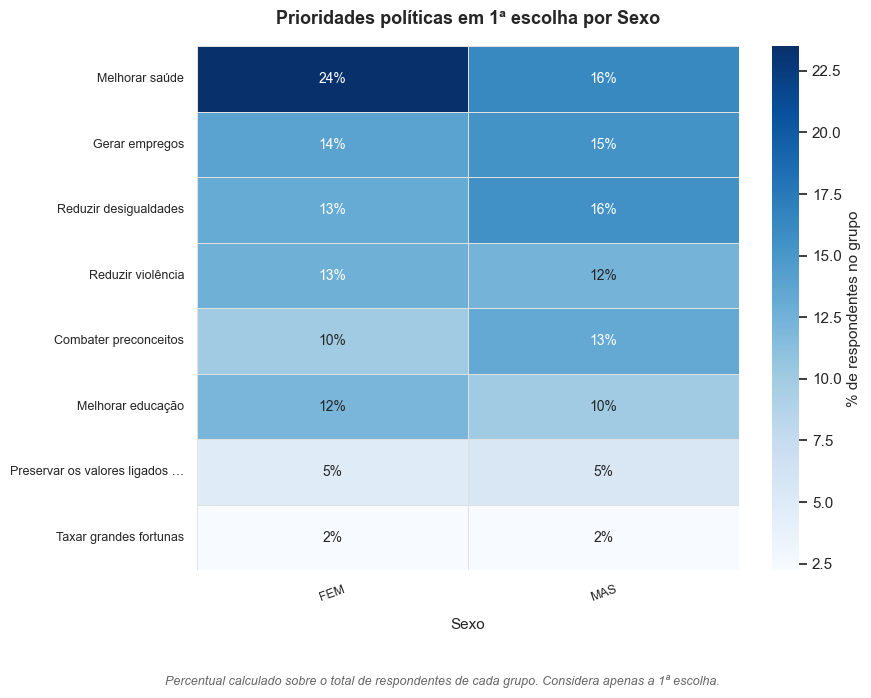

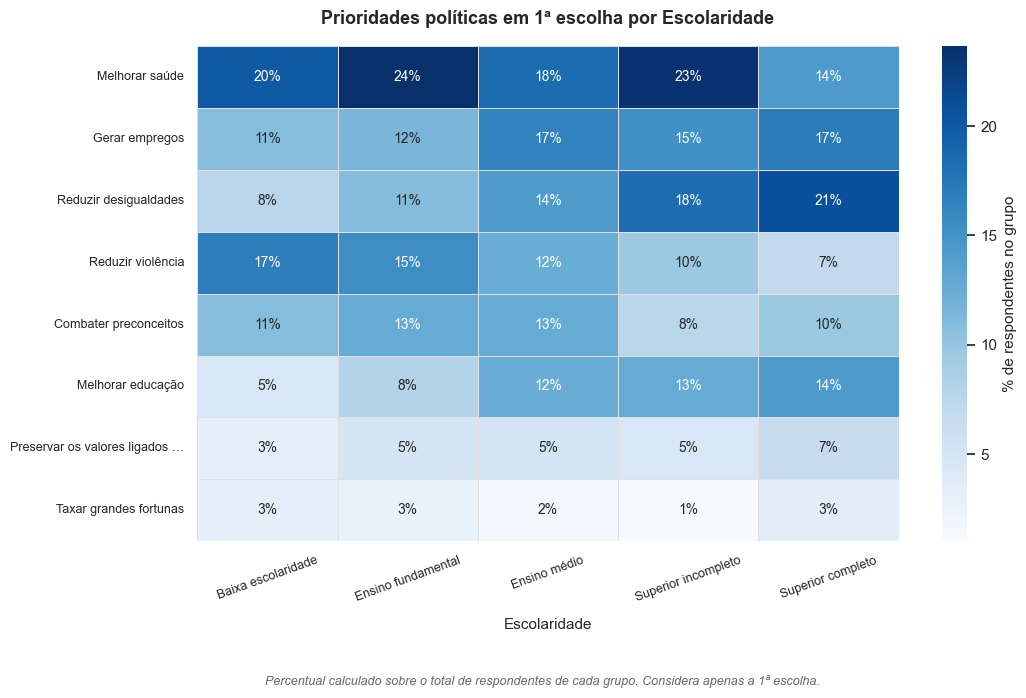

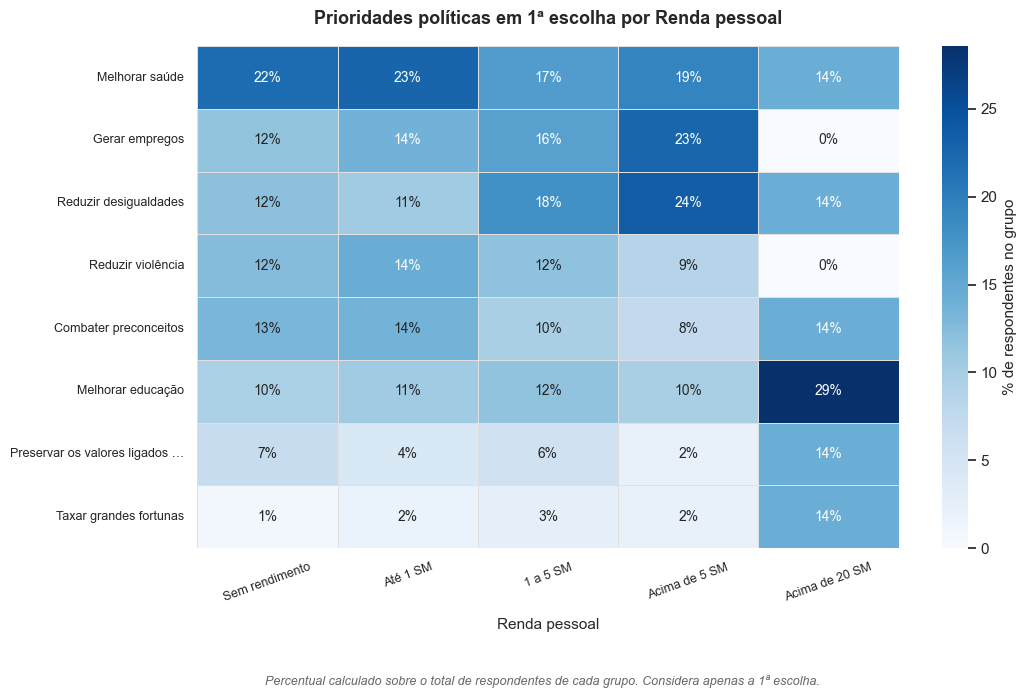

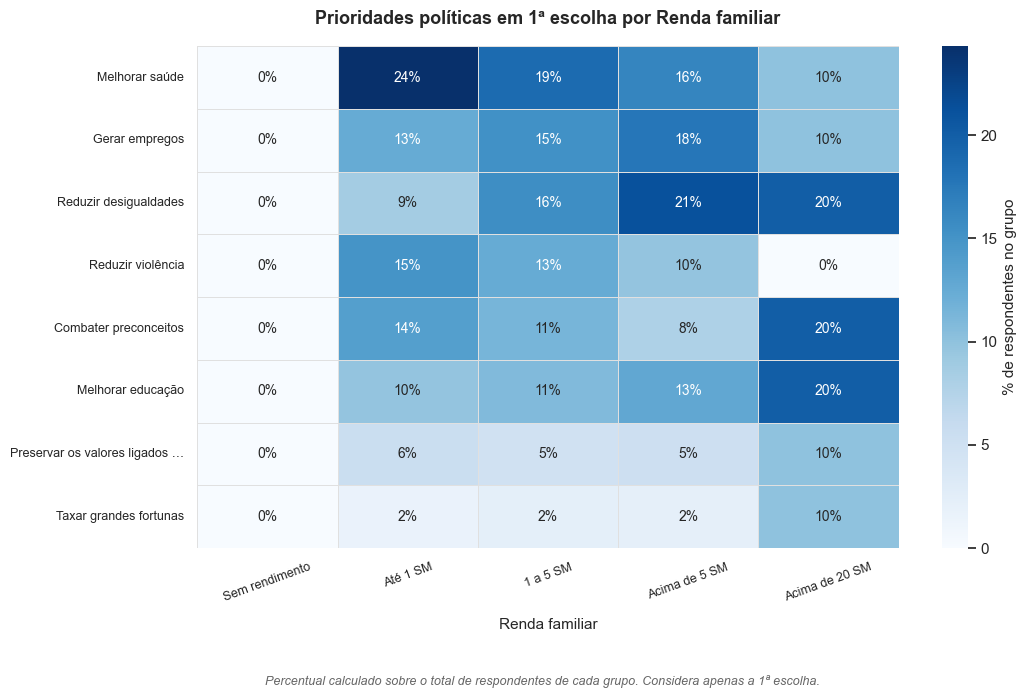

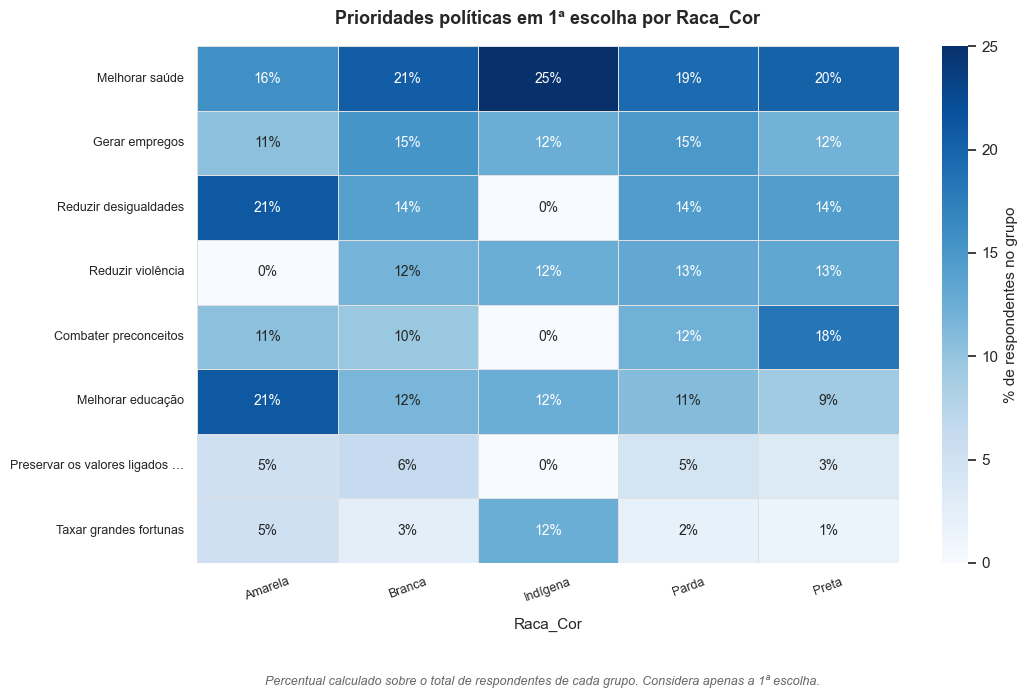

In [159]:
# === Heatmaps de prioridades em 1ª escolha × dimensões sociodemográficas ===
# Replica o padrão do heatmap por região para: sexo, escolaridade, renda e raça/cor.
# Denominador: total de respondentes por grupo (independente de responder P_02_1).

def _heatmap_prio_dim(col_name, titulo_eixo, ordem_cols=None):
    """Plota heatmap de prioridades em 1ª escolha × dimensão sociodemográfica."""
    df_aux = df_cesop.assign(P_ABREV=df_cesop["P_02_1"].map(_abrev_prio))

    col_totals = df_aux.dropna(subset=[col_name])[col_name].value_counts()

    ct_abs = pd.crosstab(
        df_aux.dropna(subset=["P_ABREV", col_name])["P_ABREV"],
        df_aux.dropna(subset=["P_ABREV", col_name])[col_name],
    )
    ct_pct = ct_abs.div(col_totals, axis=1).fillna(0) * 100

    # Reordena linhas (prioridades por frequência geral) e colunas (ordem lógica se fornecida).
    ct_pct = ct_pct.reindex(index=[p for p in top8_abrev if p in ct_pct.index])
    if ordem_cols:
        ct_pct = ct_pct.reindex(columns=[c for c in ordem_cols if c in ct_pct.columns])

    # Figsize adaptado ao número de colunas.
    n_cols = len(ct_pct.columns)
    figsize = (max(9, n_cols * 2.2), 7)

    annot = ct_pct.round(0).astype(int).astype(str) + "%"

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        ct_pct,
        annot=annot, fmt="",
        cmap="Blues",
        ax=ax,
        linewidths=0.5, linecolor="#e0e0e0",
        cbar_kws={"label": "% de respondentes no grupo"},
        annot_kws={"size": 10},
    )
    ax.set_title(f"Prioridades políticas em 1ª escolha por {titulo_eixo}", pad=16)
    ax.set_xlabel(titulo_eixo, labelpad=10)
    ax.set_ylabel("")
    ax.tick_params(axis="x", rotation=20, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)

    fig.text(
        0.5, 0.01,
        "Percentual calculado sobre o total de respondentes de cada grupo. "
        "Considera apenas a 1ª escolha.",
        ha="center", fontsize=9, color="#666666", style="italic",
    )
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.savefig(PATH_FIGURAS / f"03_prioridade_politica_primeira_escolha_{titulo_eixo}.png", dpi=120, bbox_inches="tight")
    plt.show()


# Ordens semânticas para variáveis com sequência lógica.
ORDEM_RENDA_HM  = ['Sem rendimento', 'Até 1 SM', '1 a 5 SM', 'Acima de 5 SM', 'Acima de 20 SM']
ORDEM_ESCOL_HM  = ['Baixa escolaridade', 'Ensino fundamental', 'Ensino médio', 'Superior incompleto', 'Superior completo' ]

_heatmap_prio_dim("SEXO",           "Sexo")
_heatmap_prio_dim("ESCOL_GRUPO",    "Escolaridade",   ordem_cols=ORDEM_ESCOL_HM)
_heatmap_prio_dim("RENDA_PESSOAL",  "Renda pessoal",  ordem_cols=ORDEM_RENDA_HM)
_heatmap_prio_dim("RENDA_FAMILIAR", "Renda familiar", ordem_cols=ORDEM_RENDA_HM)
_heatmap_prio_dim("RACA",           "Raca_Cor")


## 4. Combate às fake news

A pergunta P.03 listou diferentes medidas que poderiam combater a divulgação de fake news. Cada respondente podia citar **de 1 a 6 medidas** (múltipla escolha).

A seção está organizada em quatro partes:

1. **Ranking das medidas** — quais aparecem com maior frequência no total de menções.
2. **Quantidade por respondente** — o respondente tende a citar poucas ou muitas medidas?
3. **Por tipo de ação** — regulamentação versus punição / responsabilização.
4. **Por ator responsabilizado** — usuários, plataformas ou políticos.

Como cada respondente pôde citar mais de uma medida, **os percentuais se referem ao total de menções, não ao total de respondentes**. Esse ponto é essencial para a interpretação correta dos dados.

> Rótulos das medidas foram abreviados para fins de visualização.

[OK] Todas as respostas foram mapeadas com sucesso!


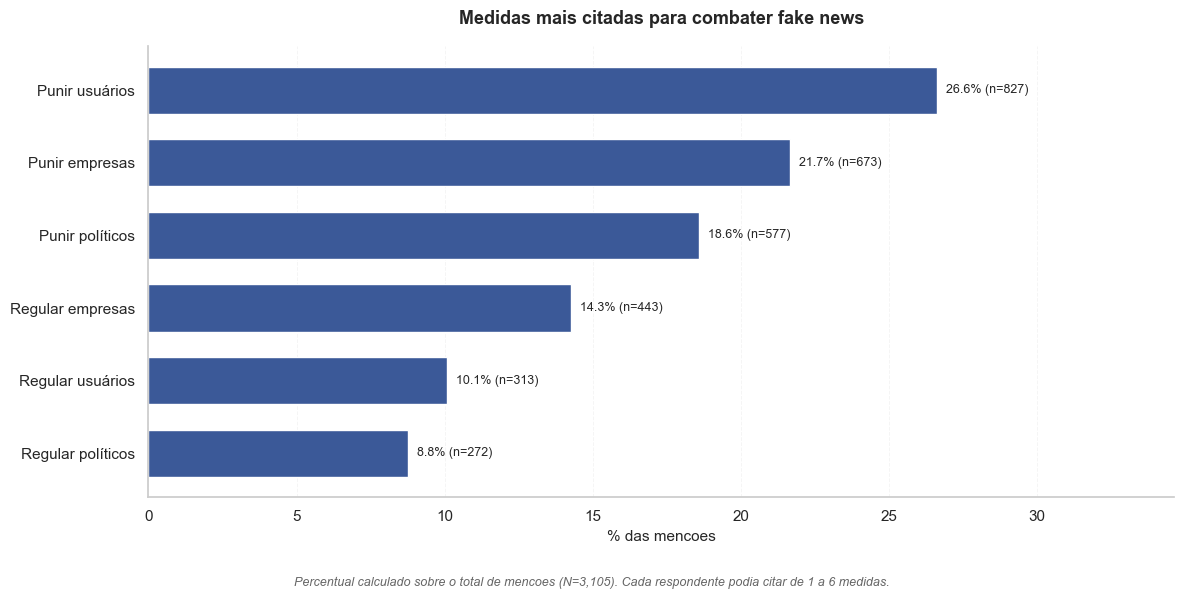

Tabela 1 — Medidas mais citadas (total de mencoes = 3,105)


,Mencoes,% das mencoes
Punir usuários,827,26.6%
Punir empresas,673,21.7%
Punir políticos,577,18.6%
Regular empresas,443,14.3%
Regular usuários,313,10.1%
Regular políticos,272,8.8%


In [166]:
from IPython.display import display

# === Dados e helpers compartilhados — seção 4 (Combate às fake news) ===
cols_p3 = [f"P_03_{i}" for i in range(1, 7)]
todas_medidas_raw = pd.concat([df_cesop[c] for c in cols_p3], ignore_index=True).dropna()
TOTAL_MENC_P3 = len(todas_medidas_raw)


# === MAPEAMENTO_P03: DE/PARA fixo (correspondência exata, sem regex) ===
MAPEAMENTO_P03 = {
    "Ampliar a regulamentação para políticos que divulgam fake news, criadas por eles próprios ou por terceiros": {
        "rótulo": "Regular políticos",
        "tipo": "Regulamentação",
        "ator": "Políticos"
    },
    "Ampliar a regulamentação para usuários que divulgam fake news, criadas por eles próprios ou por terceiros": {
        "rótulo": "Regular usuários",
        "tipo": "Regulamentação",
        "ator": "Usuários"
    },
    "Ampliar a regulamentação, as regras a serem cumpridas pelas plataformas digitais (Facebook, Youtube, WhatsApp, etc.)": {
        "rótulo": "Regular empresas",
        "tipo": "Regulamentação",
        "ator": "Empresas / Plataformas"
    },
    "Responsabilizar e punir as empresas de tecnologia/comunicação que não removerem postagens com conteúdos falsos": {
        "rótulo": "Punir empresas",
        "tipo": "Punição / Responsabilização",
        "ator": "Empresas / Plataformas"
    },
    "Responsabilizar e punir os usuários que divulgam ou compartilham postagens com notícias ou conteúdos falsos": {
        "rótulo": "Punir usuários",
        "tipo": "Punição / Responsabilização",
        "ator": "Usuários"
    },
    "Responsabilizar, punir ou caçar políticos que divulgam ou compartilham postagens com notícias ou conteúdos falsos": {
        "rótulo": "Punir políticos",
        "tipo": "Punição / Responsabilização",
        "ator": "Políticos"
    }
}


def _classifica_p03(resposta_original):
    """Retorna (rótulo, tipo, ator) ou (None, None, None) se não mapeado."""
    if resposta_original in MAPEAMENTO_P03:
        m = MAPEAMENTO_P03[resposta_original]
        return m["rótulo"], m["tipo"], m["ator"]
    return None, None, None


# Aplica o mapeamento a todas as respostas.
todas_medidas_abrev = todas_medidas_raw.map(lambda x: _classifica_p03(x)[0])
todas_medidas_tipo = todas_medidas_raw.map(lambda x: _classifica_p03(x)[1])
todas_medidas_ator = todas_medidas_raw.map(lambda x: _classifica_p03(x)[2])

# Auditoria: valores não mapeados
nao_mapeados = todas_medidas_raw[todas_medidas_abrev.isna()].value_counts()
if len(nao_mapeados) > 0:
    print("" + "="*100)
    print("AUDITORIA: Respostas NAO mapeadas em MAPEAMENTO_P03")
    print("="*100)
    for resposta, count in nao_mapeados.items():
        print(f"  [{count}x] {resposta[:90]}")
    print("="*100 + "")
else:
    print("[OK] Todas as respostas foram mapeadas com sucesso!")


# === Gráfico 1: Ranking das medidas ===
freq_med = todas_medidas_abrev.value_counts()
df_med = pd.DataFrame({"n": freq_med, "pct": freq_med / TOTAL_MENC_P3 * 100})
df_med = df_med.sort_values("pct")

fig, ax = plt.subplots(figsize=(12, max(6, len(df_med) * 0.65)))
bars = ax.barh(df_med.index, df_med["pct"], color=COR_PRINCIPAL, height=0.65)

ax.set_title("Medidas mais citadas para combater fake news", pad=16)
ax.set_xlabel("% das mencoes")
ax.set_xlim(0, df_med["pct"].max() * 1.30)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, pct, n in zip(bars, df_med["pct"], df_med["n"]):
    ax.text(pct + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=9)

fig.text(
    0.5, 0.01,
    f"Percentual calculado sobre o total de mencoes (N={TOTAL_MENC_P3:,}). "
    "Cada respondente podia citar de 1 a 6 medidas.",
    ha="center", fontsize=9, color="#666666", style="italic",
)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print(f"Tabela 1 — Medidas mais citadas (total de mencoes = {TOTAL_MENC_P3:,})")
tab_med = df_med[["n", "pct"]].sort_values("pct", ascending=False).copy()
tab_med.columns = ["Mencoes", "% das mencoes"]
tab_med["% das mencoes"] = tab_med["% das mencoes"].map("{:.1f}%".format)
display(tab_med)

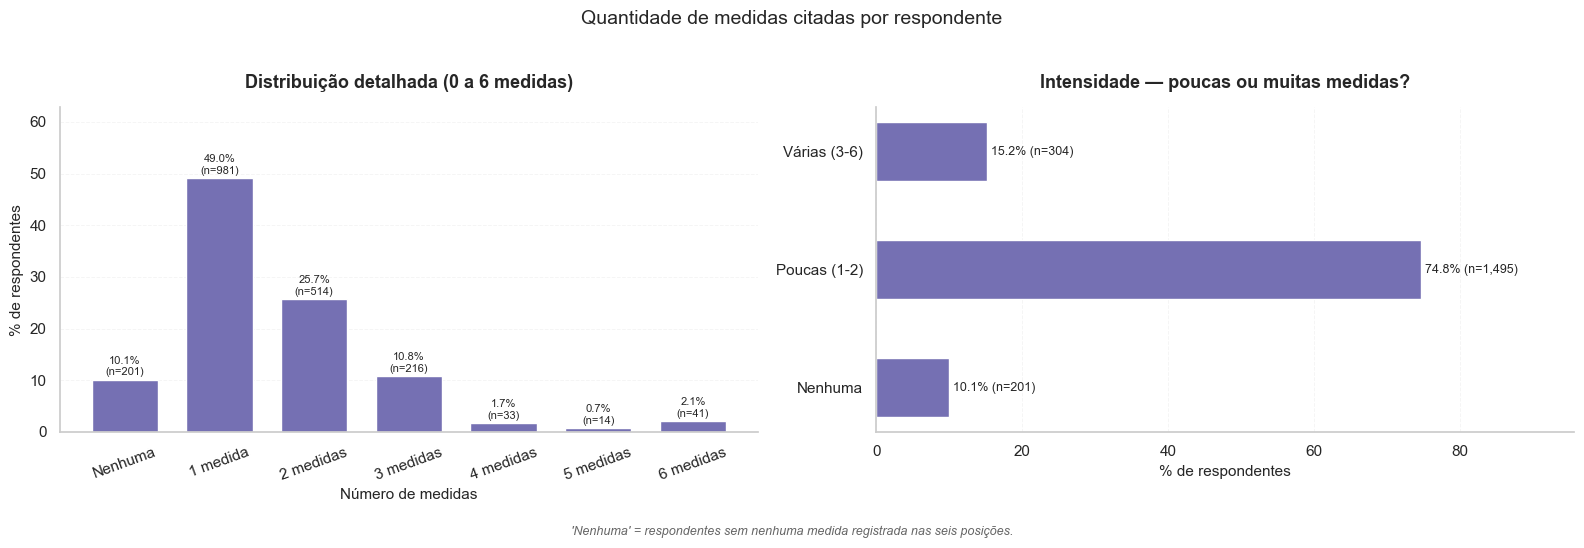


Tabela 2 — Distribuição de medidas por respondente (n=2,000)


,Respondentes,% de respondentes
Nenhuma,201,10.1%
1 medida,981,49.0%
2 medidas,514,25.7%
3 medidas,216,10.8%
4 medidas,33,1.7%
5 medidas,14,0.7%
6 medidas,41,2.1%


In [164]:
# === Gráfico 2: Quantidade de medidas citadas por respondente + Intensidade ===
COR_DIST = "#7570b3"

n_medidas = df_cesop[cols_p3].notna().sum(axis=1)
dist_n   = n_medidas.value_counts().sort_index()
dist_pct = dist_n / len(df_cesop) * 100

x_full_labels = {
    0: "Nenhuma", 1: "1 medida", 2: "2 medidas", 3: "3 medidas",
    4: "4 medidas", 5: "5 medidas", 6: "6 medidas",
}

# --- Agrupamento de intensidade ---
def _grupo_intens(n):
    if n == 0:  return "Nenhuma"
    if n <= 2:  return "Poucas (1-2)"
    return "Várias (3-6)"

grupos_intens = n_medidas.map(_grupo_intens).value_counts()
ordem_g = ["Nenhuma", "Poucas (1-2)", "Várias (3-6)"]
df_g = pd.DataFrame({"n": grupos_intens, "pct": grupos_intens / len(df_cesop) * 100})
df_g = df_g.reindex([g for g in ordem_g if g in df_g.index])

fig, (ax_a, ax_b) = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Quantidade de medidas citadas por respondente", fontsize=14, y=1.02)

# --- Painel A: distribuição detalhada (barras verticais — eixo tem ordem natural 0-6) ---
bars_a = ax_a.bar(
    [x_full_labels.get(i, str(i)) for i in dist_pct.index],
    dist_pct.values,
    color=COR_DIST, width=0.7,
)
ax_a.set_title("Distribuição detalhada (0 a 6 medidas)", pad=14)
ax_a.set_xlabel("Número de medidas")
ax_a.set_ylabel("% de respondentes")
ax_a.set_ylim(0, dist_pct.max() * 1.28)
ax_a.grid(axis="x", visible=False)
ax_a.grid(axis="y", alpha=0.2, linestyle="--", linewidth=0.7)
ax_a.spines["top"].set_visible(False)
ax_a.spines["right"].set_visible(False)
ax_a.tick_params(axis="x", rotation=20)

for bar, pct, n in zip(bars_a, dist_pct.values, dist_n.values):
    ax_a.text(bar.get_x() + bar.get_width() / 2, pct + 0.5,
              f"{pct:.1f}%\n(n={int(n):,})", ha="center", va="bottom", fontsize=8)

# --- Painel B: intensidade (barras horizontais) ---
bars_b = ax_b.barh(df_g.index, df_g["pct"], color=COR_DIST, height=0.5)
ax_b.set_title("Intensidade — poucas ou muitas medidas?", pad=14)
ax_b.set_xlabel("% de respondentes")
ax_b.set_xlim(0, df_g["pct"].max() * 1.28)
ax_b.set_ylabel("")
ax_b.grid(axis="y", visible=False)
ax_b.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)

for bar, pct, n in zip(bars_b, df_g["pct"], df_g["n"]):
    ax_b.text(pct + 0.5, bar.get_y() + bar.get_height() / 2,
              f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=9)

fig.text(0.5, -0.03,
         "'Nenhuma' = respondentes sem nenhuma medida registrada nas seis posições.",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout()
plt.savefig(PATH_FIGURAS / f"04_qtd_medidas_citadas_por_respondente.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"\nTabela 2 — Distribuição de medidas por respondente (n={len(df_cesop):,})")
tab_dist = pd.DataFrame({"n": dist_n, "pct": dist_pct})
tab_dist.index = [x_full_labels.get(i, str(i)) for i in tab_dist.index]
tab_dist.columns = ["Respondentes", "% de respondentes"]
tab_dist["% de respondentes"] = tab_dist["% de respondentes"].map("{:.1f}%".format)
display(tab_dist)

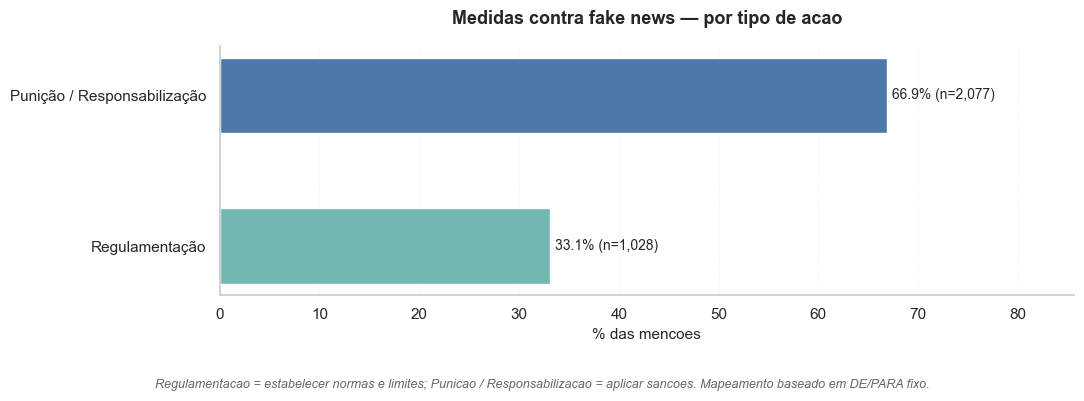

Tabela 3 — Mencoes por tipo de acao (total = 3,105)


,Mencoes,% das mencoes
Punição / Responsabilização,2077,66.9%
Regulamentação,1028,33.1%


In [178]:
# === Gráfico 3: Por tipo de acao ===
CORES_TIPO = {
    "Regulamentação":              "#72B7B2",
    "Punição / Responsabilização": "#4C78A8",
}

tipo_counts = todas_medidas_tipo.dropna().value_counts()
df_tipo = pd.DataFrame({"n": tipo_counts, "pct": tipo_counts / TOTAL_MENC_P3 * 100})
df_tipo = df_tipo.sort_values("pct")
cores_tipo = [CORES_TIPO.get(c, "#aaaaaa") for c in df_tipo.index]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(df_tipo.index, df_tipo["pct"], color=cores_tipo, height=0.5)

ax.set_title("Medidas contra fake news — por tipo de acao", pad=16)
ax.set_xlabel("% das mencoes")
ax.set_xlim(0, df_tipo["pct"].max() * 1.28)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, pct, n in zip(bars, df_tipo["pct"], df_tipo["n"]):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=10)

fig.text(0.5, 0.01,
         "Regulamentacao = estabelecer normas e limites; "
         "Punicao / Responsabilizacao = aplicar sancoes. "
         "Mapeamento baseado em DE/PARA fixo.",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(PATH_FIGURAS / f"04_medidas_contra_fake_news_tipo_acao.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Tabela 3 — Mencoes por tipo de acao (total = {TOTAL_MENC_P3:,})")
tab_tipo = df_tipo[["n", "pct"]].sort_values("pct", ascending=False).copy()
tab_tipo.columns = ["Mencoes", "% das mencoes"]
tab_tipo["% das mencoes"] = tab_tipo["% das mencoes"].map("{:.1f}%".format)
display(tab_tipo)


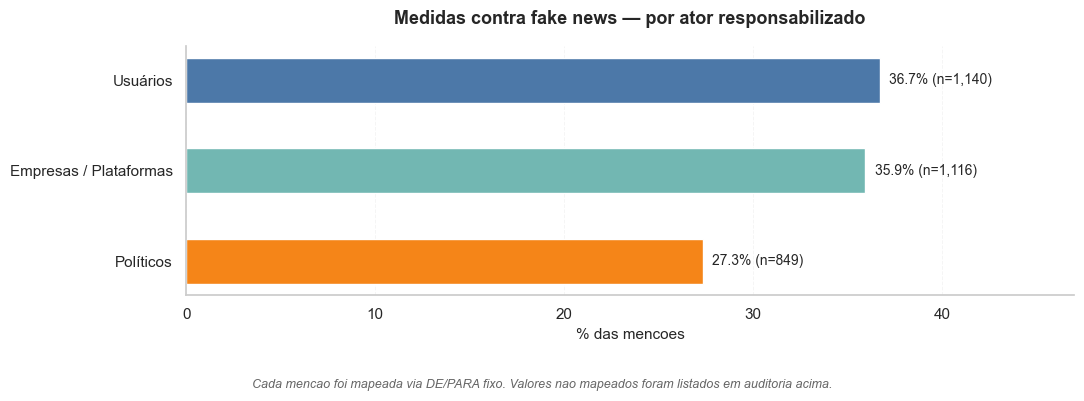

Tabela 4 — Mencoes por ator responsabilizado (total = 3,105)


,Mencoes,% das mencoes
Usuários,1140,36.7%
Empresas / Plataformas,1116,35.9%
Políticos,849,27.3%


In [174]:
# === Gráfico 4: Por ator responsabilizado ===
CORES_ATOR = {
    "Políticos":              "#F58518",
    "Empresas / Plataformas": "#72B7B2",
    "Usuários":               "#4C78A8",
}

ator_counts = todas_medidas_ator.dropna().value_counts()
df_ator = pd.DataFrame({"n": ator_counts, "pct": ator_counts / TOTAL_MENC_P3 * 100})
df_ator = df_ator.sort_values("pct")
cores_ator = [CORES_ATOR.get(c, "#aaaaaa") for c in df_ator.index]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.barh(df_ator.index, df_ator["pct"], color=cores_ator, height=0.5)

ax.set_title("Medidas contra fake news — por ator responsabilizado", pad=16)
ax.set_xlabel("% das mencoes")
ax.set_xlim(0, df_ator["pct"].max() * 1.28)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, pct, n in zip(bars, df_ator["pct"], df_ator["n"]):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=10)

fig.text(0.5, 0.01,
         "Cada mencao foi mapeada via DE/PARA fixo. "
         "Valores nao mapeados foram listados em auditoria acima.",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig(PATH_FIGURAS / f"04_medidas_contra_fake_news_ator_responsabilizado.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Tabela 4 — Mencoes por ator responsabilizado (total = {TOTAL_MENC_P3:,})")
tab_ator = df_ator[["n", "pct"]].sort_values("pct", ascending=False).copy()
tab_ator.columns = ["Mencoes", "% das mencoes"]
tab_ator["% das mencoes"] = tab_ator["% das mencoes"].map("{:.1f}%".format)
display(tab_ator)


## 5. Vontade de participar da vida política local

A pergunta P.04 investigou a disposição declarada dos respondentes para participar da vida política em sua cidade, com três níveis de intensidade: *Muita vontade*, *Alguma vontade* e *Nenhuma vontade*.

A análise é organizada em três partes:

1. **Distribuição geral** — qual é o nível predominante na amostra.
2. **Perfil demográfico** — variação por faixa etária, escolaridade, sexo e raça/cor.
3. **Perfil socioeconômico e territorial** — variação por renda e região.

A análise é descritiva — observa padrões na amostra sem inferir causalidade. Grupos com baixo n devem ser interpretados com cautela.

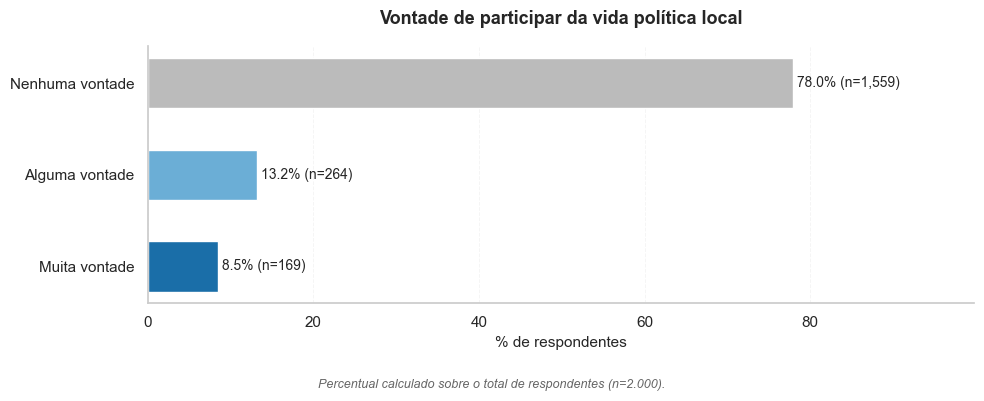


Tabela: Distribuição geral de vontade de participação política


,n,% de respondentes
P_04,,
Muita vontade,169,8.5%
Alguma vontade,264,13.2%
Nenhuma vontade,1559,78.0%


In [109]:
from IPython.display import display

# === Constantes e helpers compartilhados — seção 5 (Vontade de participar) ===

REGIAO_MAP_P4  = {"NORTE": "Norte", "NORDESTE": "Nordeste", "SUL": "Sul",
                   "SUDESTE": "Sudeste", "CENTRO OESTE": "Centro-Oeste"}
ORDEM_REGIAO_P4 = ["Norte", "Nordeste", "Centro-Oeste", "Sudeste", "Sul"]
ORDEM_FX_P4     = ["16 E 17", "18 A 24", "25 A 34", "35 A 44", "45 A 54", "55 A 64", "65 E MAIS"]
ORDEM_ESCOL_P4  = ["Analfabeto", "Lê e escreve", "Até fundamental", "Ensino médio",
                    "Superior incompleto", "Superior completo"]
ORDEM_RENDA_P4  = ["Até 1 salário mínimo", "1 a 5 salários mínimos",
                    "Acima de 5 salários mínimos", "Acima de 20 salários mínimos"]

LIMIAR_P4 = 5.0  # segmentos < 5% não recebem rótulo interno


def _cor_p4(cat):
    """Paleta neutra e acadêmica para os três níveis de vontade."""
    c = str(cat).lower()
    if "muita" in c:   return "#1a6ea8"  # azul escuro
    if "alguma" in c:  return "#6baed6"  # azul claro
    if "nenhuma" in c: return "#bbbbbb"  # cinza médio
    return "#cccccc"


def _txt_p4(cat):
    c = str(cat).lower()
    return "#333333" if "nenhuma" in c else "white"


def _rotulos_p4(ax, colunas):
    """Rótulos inteiros no centro de cada segmento; omite segmentos < LIMIAR_P4."""
    for i, container in enumerate(ax.containers):
        cat = colunas[i]
        cor_txt = _txt_p4(cat)
        for bar in container:
            val = bar.get_width()
            if pd.isna(val) or val < LIMIAR_P4:
                continue
            x = bar.get_x() + val / 2
            y = bar.get_y() + bar.get_height() / 2
            ax.text(x, y, f"{int(round(val))}%", ha="center", va="center",
                    fontsize=9, color=cor_txt, fontweight="bold")


# Descobre valores e ordem (Muita → Alguma → Nenhuma) dinamicamente.
vals_p4   = df_cesop["P_04"].dropna().unique().tolist()
ordem_p4_s5 = sorted(vals_p4,
                      key=lambda v: {"muita": 0, "alguma": 1, "nenhuma": 2}
                      .get(str(v).lower().split()[0], 99))

contagem_p4 = df_cesop["P_04"].value_counts().reindex(ordem_p4_s5)
pct_p4_ser  = contagem_p4 / len(df_cesop) * 100
cores_p4    = [_cor_p4(c) for c in ordem_p4_s5]


# === Gráfico geral: barras horizontais ===
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.barh(ordem_p4_s5, pct_p4_ser.values, color=cores_p4, height=0.55)

ax.set_title("Vontade de participar da vida política local", pad=16)
ax.set_xlabel("% de respondentes")
ax.set_xlim(0, pct_p4_ser.max() * 1.28)
ax.set_ylabel("")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bar, pct, n in zip(bars, pct_p4_ser.values, contagem_p4.values):
    ax.text(pct + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}% (n={int(n):,})", va="center", fontsize=10)

fig.text(0.5, 0.01,
         "Percentual calculado sobre o total de respondentes (n=2.000).",
         ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

print("\nTabela: Distribuição geral de vontade de participação política")
tab_p4 = pd.DataFrame({
    "n": contagem_p4,
    "% de respondentes": pct_p4_ser.map("{:.1f}%".format),
})
display(tab_p4)

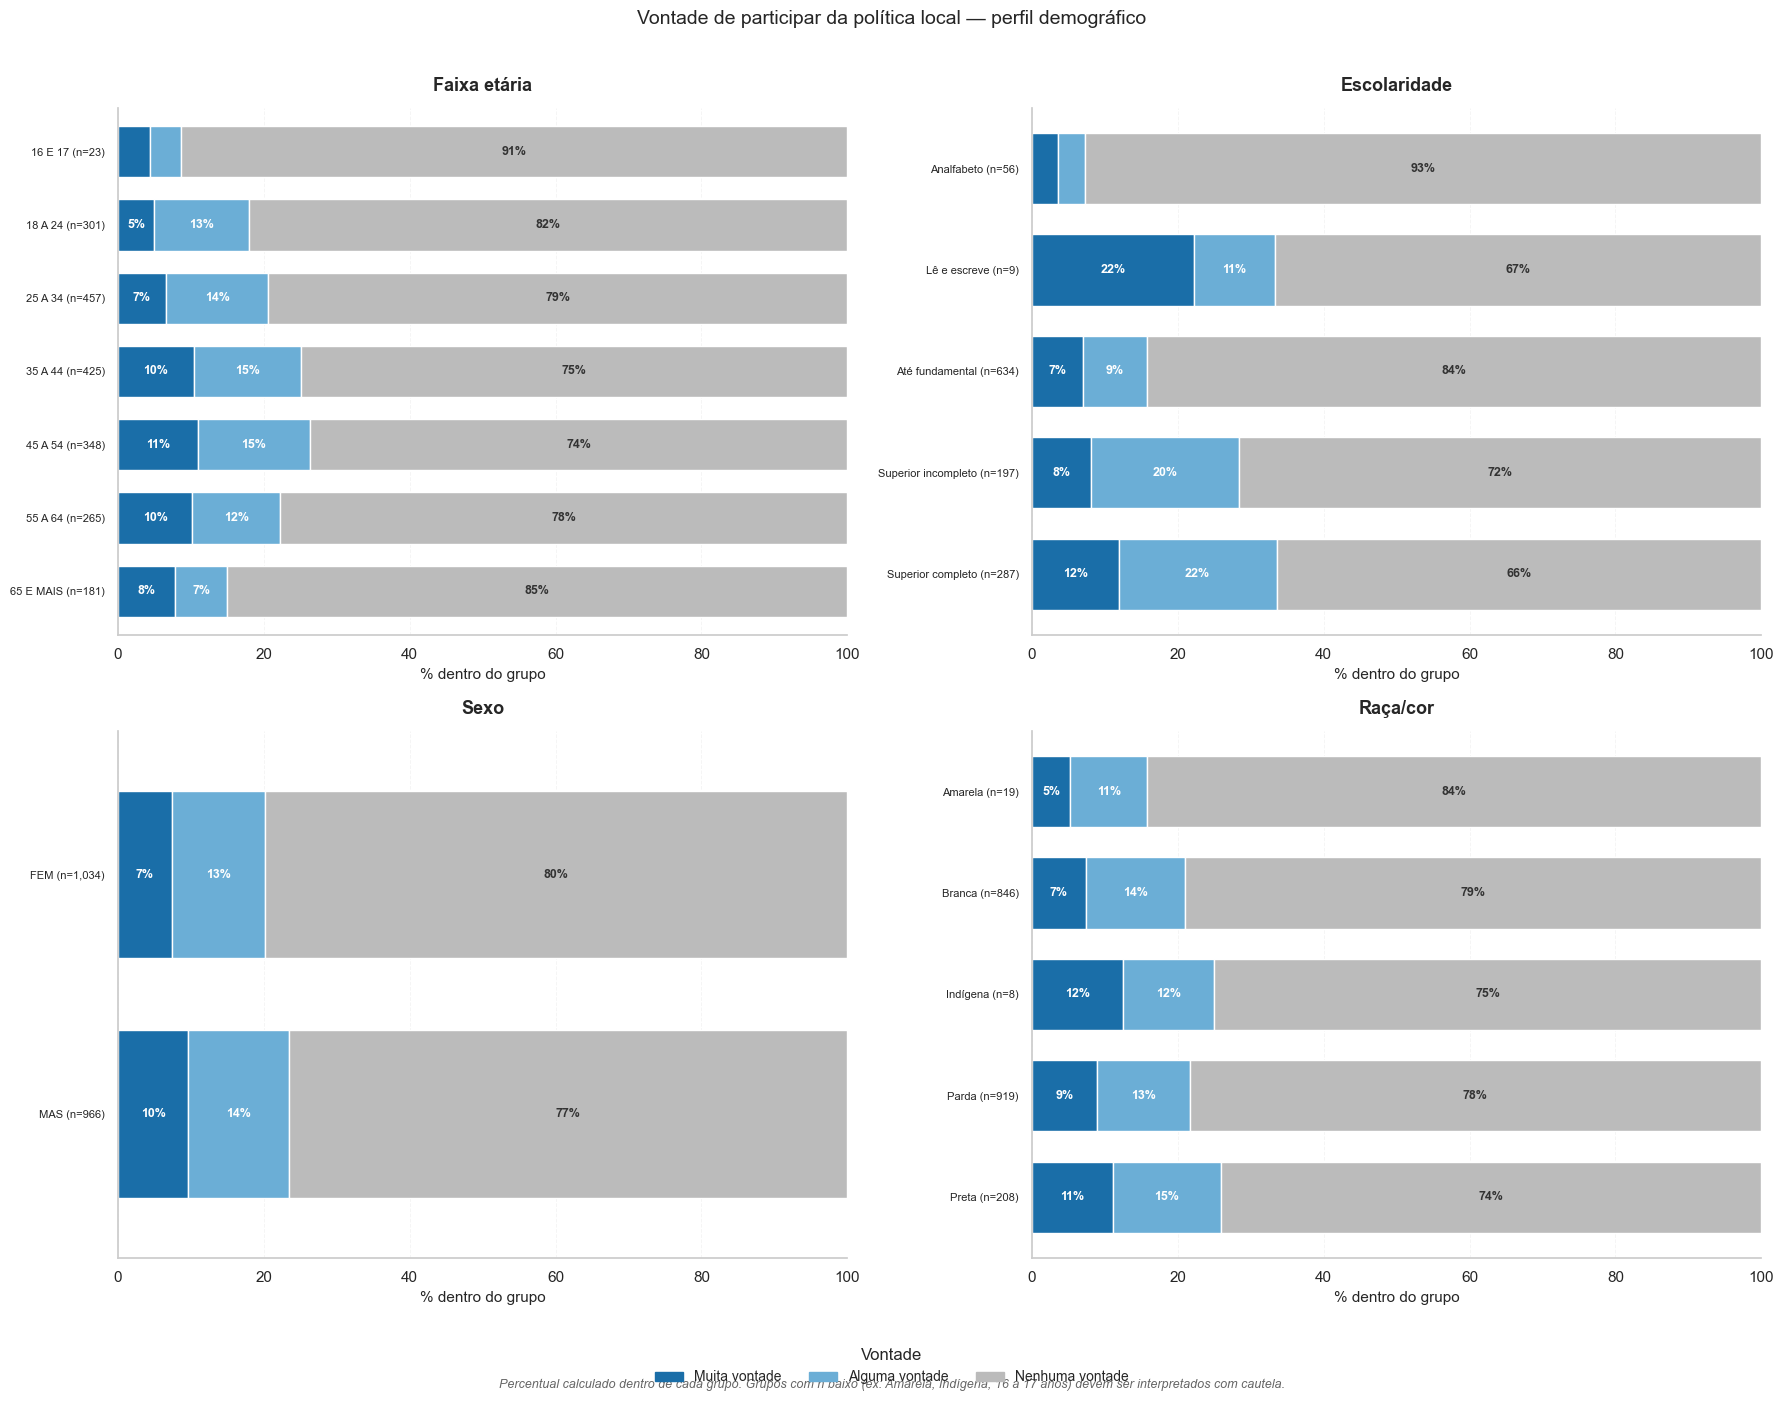

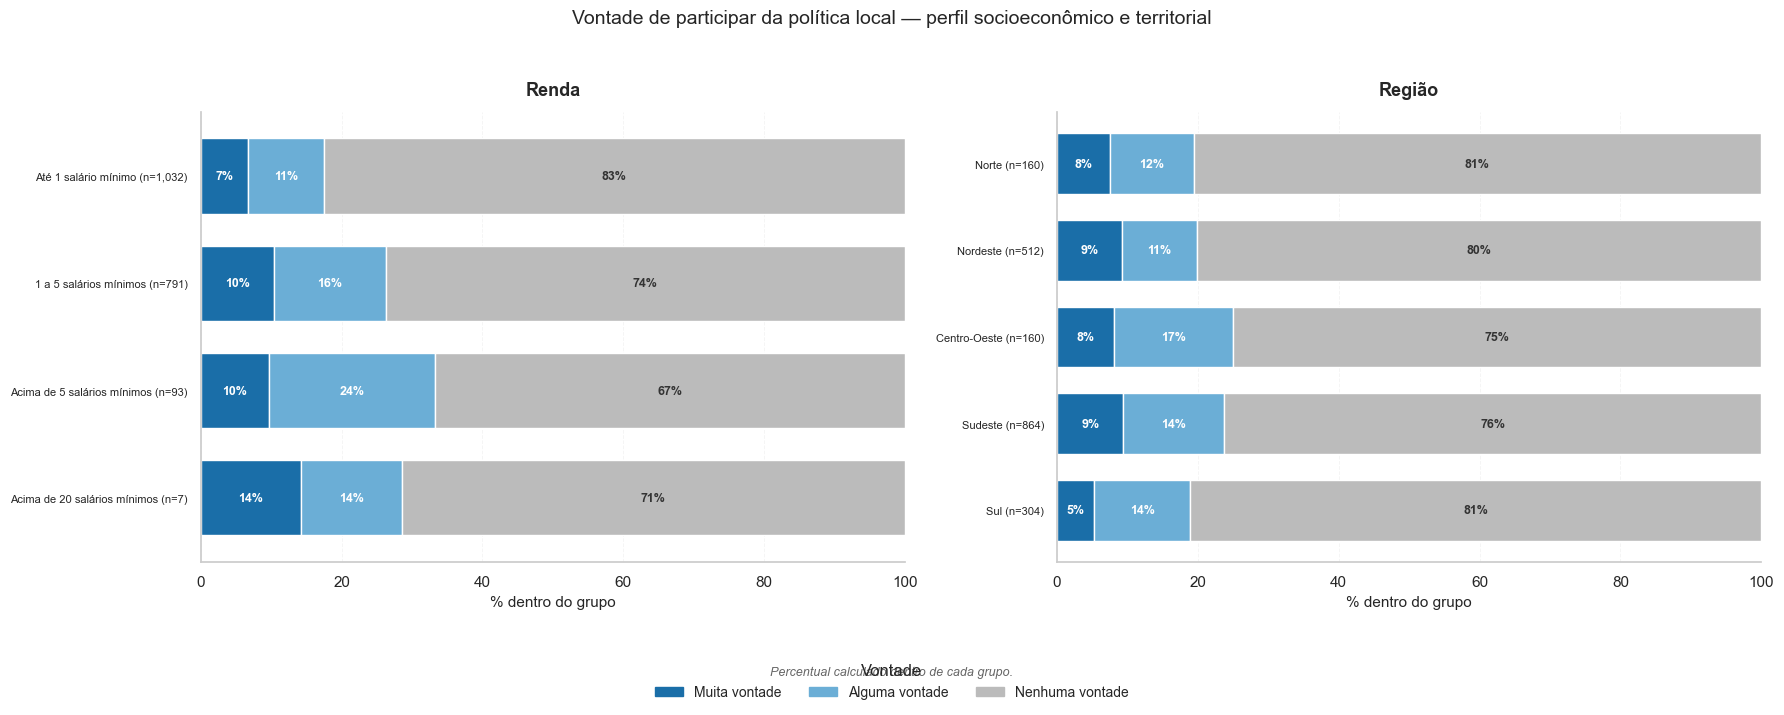

In [110]:
# === Cruzamentos: vontade de participar × perfil sociodemográfico ===
# df_p4w adiciona REGIAO_DISP com nomes em caixa mista para exibição.
df_p4w = df_cesop.assign(
    REGIAO_DISP = df_cesop["REGIAO"].map(REGIAO_MAP_P4).fillna(df_cesop["REGIAO"].astype(str))
)

# Detecta coluna de renda disponível.
col_renda = next((c for c in ["RENDA_PESSOAL", "RENDA_GRUPO"] if c in df_p4w.columns), None)


def _cross_p4(col, ax, title, ordem_col=None):
    """
    Barras horizontais 100% empilhadas de P_04 × col.
    Labels do eixo Y incluem n= de cada grupo.
    """
    ct = pd.crosstab(df_p4w[col], df_p4w["P_04"], normalize="index") * 100
    cols_used = [c for c in ordem_p4_s5 if c in ct.columns]
    ct = ct[cols_used]

    if ordem_col:
        ct = ct.reindex([c for c in ordem_col if c in ct.index])

    n_grp = df_p4w[col].value_counts()
    labels_y = [f"{cat} (n={int(n_grp.get(cat, 0)):,})" for cat in ct.index]
    cores_used = [_cor_p4(c) for c in cols_used]

    ct.plot.barh(stacked=True, ax=ax, color=cores_used, width=0.7, legend=False)
    ax.set_yticks(range(len(ct.index)))
    ax.set_yticklabels(labels_y, fontsize=8)
    ax.invert_yaxis()

    ax.set_title(title, pad=12)
    ax.set_xlabel("% dentro do grupo")
    ax.set_ylabel("")
    ax.set_xlim(0, 100)
    ax.grid(axis="y", visible=False)
    ax.grid(axis="x", alpha=0.2, linestyle="--", linewidth=0.7)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    _rotulos_p4(ax, cols_used)


# Handles de legenda compartilhada.
leg_handles = [plt.Rectangle((0, 0), 1, 1, color=_cor_p4(c)) for c in ordem_p4_s5]

# ── Painel 1: Perfil demográfico (2 × 2) ─────────────────────────────────────
fig1, axes1 = plt.subplots(2, 2, figsize=(18, 13))
fig1.suptitle("Vontade de participar da política local — perfil demográfico",
              fontsize=14, y=1.01)

_cross_p4("FX_ID",      axes1[0, 0], "Faixa etária",  ordem_col=ORDEM_FX_P4)
_cross_p4("ESCOL_GRUPO", axes1[0, 1], "Escolaridade",  ordem_col=ORDEM_ESCOL_P4)
_cross_p4("SEXO",        axes1[1, 0], "Sexo")
_cross_p4("RACA",        axes1[1, 1], "Raça/cor")

fig1.legend(leg_handles, ordem_p4_s5, title="Vontade", loc="upper center",
            bbox_to_anchor=(0.5, -0.01), ncol=len(ordem_p4_s5), frameon=False, fontsize=10)
fig1.text(0.5, -0.05,
          "Percentual calculado dentro de cada grupo. "
          "Grupos com n baixo (ex: Amarela, Indígena, 16 a 17 anos) devem ser interpretados com cautela.",
          ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "05_vontade_demografico.png", dpi=120, bbox_inches="tight")
plt.show()


# ── Painel 2: Perfil socioeconômico e territorial (1 × 2) ────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 6))
fig2.suptitle("Vontade de participar da política local — perfil socioeconômico e territorial",
              fontsize=14, y=1.03)

if col_renda:
    _cross_p4(col_renda, axes2[0], "Renda", ordem_col=ORDEM_RENDA_P4)
else:
    axes2[0].text(0.5, 0.5, "Coluna de renda não encontrada", ha="center", va="center")

_cross_p4("REGIAO_DISP", axes2[1], "Região", ordem_col=ORDEM_REGIAO_P4)

fig2.legend(leg_handles, ordem_p4_s5, title="Vontade", loc="upper center",
            bbox_to_anchor=(0.5, -0.04), ncol=len(ordem_p4_s5), frameon=False, fontsize=10)
fig2.text(0.5, -0.08,
          "Percentual calculado dentro de cada grupo.",
          ha="center", fontsize=9, color="#666666", style="italic")
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "05_vontade_socioeconomico.png", dpi=120, bbox_inches="tight")
plt.show()

## 6. Panorama eleitoral TSE 2022

Análise descritiva do TSE: ranking de comparecimento por UF, taxa por região e gradiente por idade, escolaridade e gênero. As taxas são calculadas como `QT_COMPARECIMENTO / QT_APTOS`.


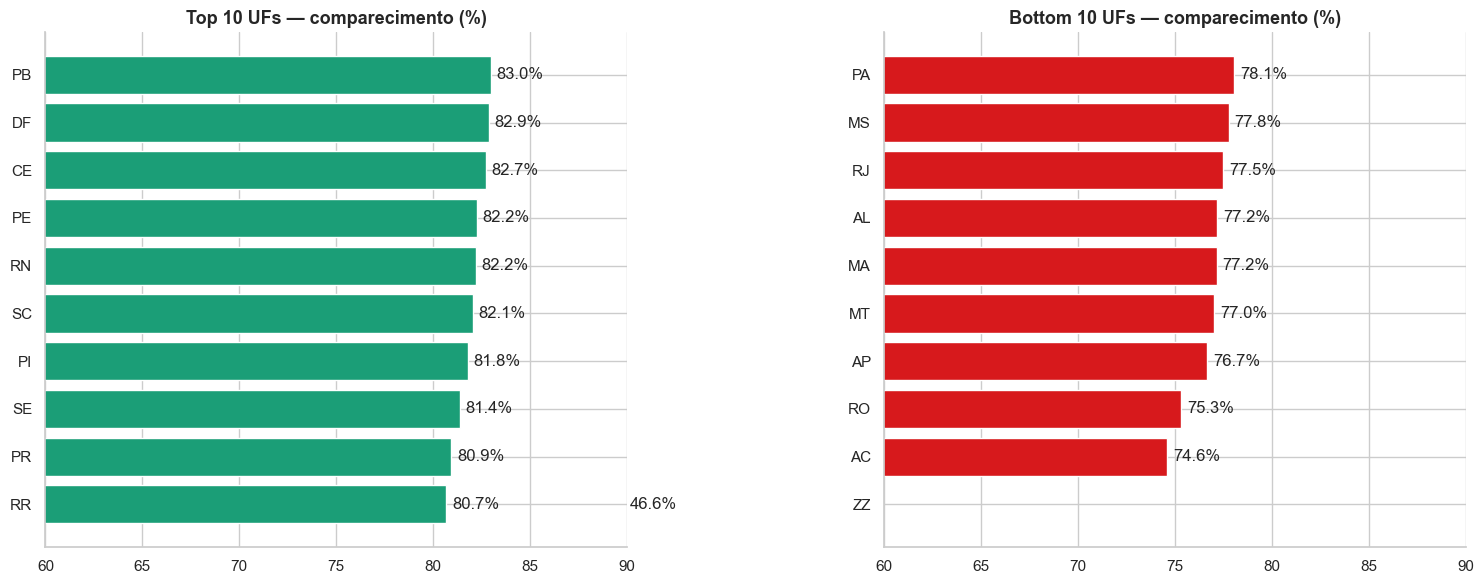

In [111]:
# Top 10 e bottom 10 UFs por taxa de comparecimento.
df_uf_sorted = df_tse_uf.sort_values("TAXA_COMPARECIMENTO")
top10 = df_uf_sorted.tail(10)
bot10 = df_uf_sorted.head(10)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(top10["SG_UF"], top10["TAXA_COMPARECIMENTO"] * 100, color="#1b9e77")
axes[0].set_title("Top 10 UFs — comparecimento (%)")
axes[0].set_xlim(60, 90)
for i, v in enumerate(top10["TAXA_COMPARECIMENTO"] * 100):
    axes[0].text(v + 0.3, i, f"{v:.1f}%", va="center")

axes[1].barh(bot10["SG_UF"], bot10["TAXA_COMPARECIMENTO"] * 100, color="#d7191c")
axes[1].set_title("Bottom 10 UFs — comparecimento (%)")
axes[1].set_xlim(60, 90)
for i, v in enumerate(bot10["TAXA_COMPARECIMENTO"] * 100):
    axes[1].text(v + 0.3, i, f"{v:.1f}%", va="center")

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "06_tse_ranking_ufs.png", dpi=120, bbox_inches="tight")
plt.show()


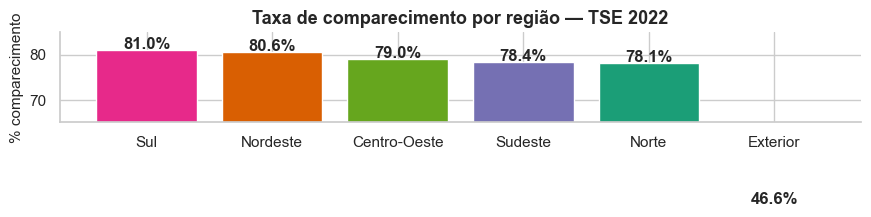

In [112]:
# Taxa de comparecimento por região — agregando os totais (não média das taxas-UF).
df_reg_tse = (df_tse_uf
    .groupby("REGIAO", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"),
         QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum"))
    .reset_index()
)
df_reg_tse["TAXA_COMPARECIMENTO"] = df_reg_tse["QT_COMPARECIMENTO"] / df_reg_tse["QT_APTOS"] * 100
df_reg_tse = df_reg_tse.sort_values("TAXA_COMPARECIMENTO", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
cores = [PALETA_REGIAO.get(r, "#999") for r in df_reg_tse["REGIAO"]]
bars = ax.bar(df_reg_tse["REGIAO"], df_reg_tse["TAXA_COMPARECIMENTO"], color=cores)
ax.set_title("Taxa de comparecimento por região — TSE 2022")
ax.set_ylabel("% comparecimento")
ax.set_ylim(65, 85)
for bar, v in zip(bars, df_reg_tse["TAXA_COMPARECIMENTO"]):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.3, f"{v:.1f}%",
            ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


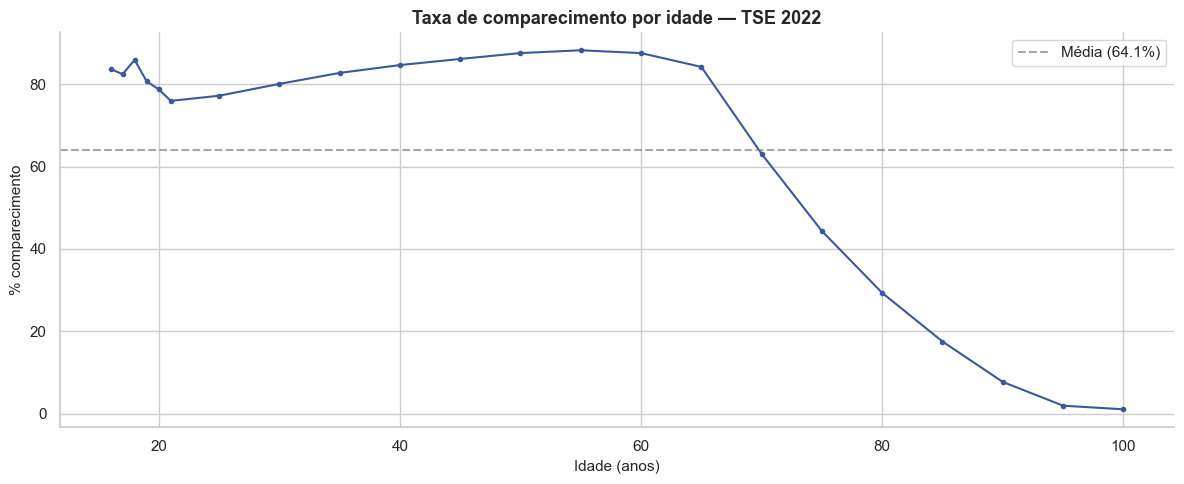

In [113]:
# Taxa de comparecimento por idade — usa a base por perfil.
# Extraímos a idade numérica a partir do texto 'X anos' para construir a curva.
def _extract_age(s):
    m = re.search(r"(\d+)", str(s))
    return int(m.group(1)) if m else np.nan

df_tse_idade = (df_tse_perfil
    .assign(IDADE=lambda d: d["DS_FAIXA_ETARIA"].map(_extract_age))
    .dropna(subset=["IDADE"])
    .groupby("IDADE")
    .agg(QT_APTOS=("QT_APTOS", "sum"),
         QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum"))
    .reset_index()
)
df_tse_idade["TAXA"] = df_tse_idade["QT_COMPARECIMENTO"] / df_tse_idade["QT_APTOS"] * 100

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_tse_idade["IDADE"], df_tse_idade["TAXA"],
        marker="o", markersize=3, color=COR_PRINCIPAL, linewidth=1.5)
ax.axhline(df_tse_idade["TAXA"].mean(), color="gray", linestyle="--", alpha=0.7,
           label=f"Média ({df_tse_idade['TAXA'].mean():.1f}%)")
ax.set_title("Taxa de comparecimento por idade — TSE 2022")
ax.set_xlabel("Idade (anos)")
ax.set_ylabel("% comparecimento")
ax.legend()
plt.tight_layout()
plt.show()


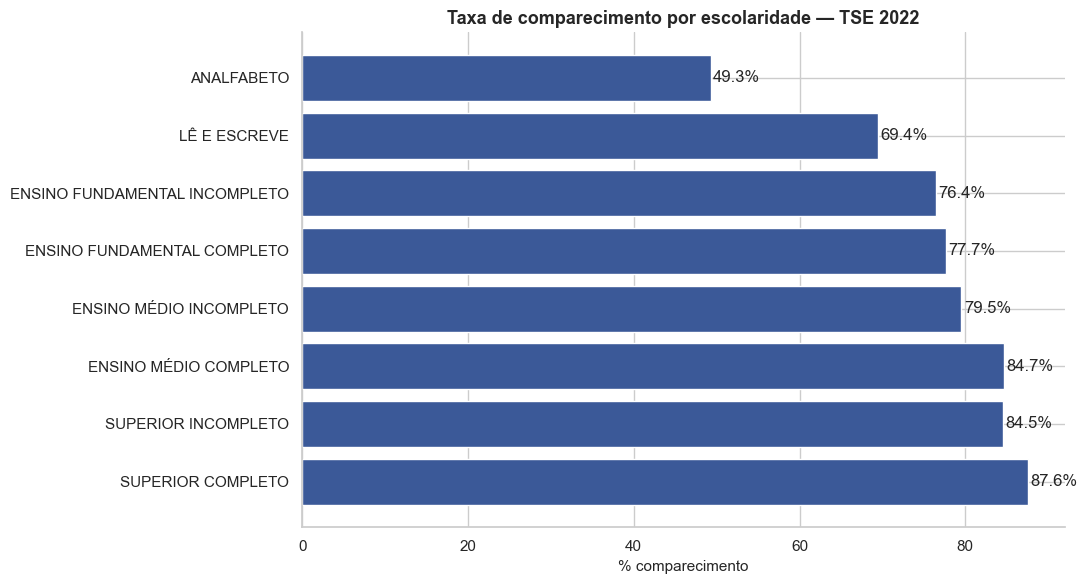

In [114]:
# Comparecimento por escolaridade — TSE.
ordem_escol_tse = [
    "ANALFABETO", "LÊ E ESCREVE",
    "ENSINO FUNDAMENTAL INCOMPLETO", "ENSINO FUNDAMENTAL COMPLETO",
    "ENSINO MÉDIO INCOMPLETO", "ENSINO MÉDIO COMPLETO",
    "SUPERIOR INCOMPLETO", "SUPERIOR COMPLETO",
]

df_escol_tse = (df_tse_perfil
    .groupby("DS_GRAU_ESCOLARIDADE", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"),
         QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum"))
)
df_escol_tse["TAXA"] = df_escol_tse["QT_COMPARECIMENTO"] / df_escol_tse["QT_APTOS"] * 100
df_escol_tse = df_escol_tse.reindex(ordem_escol_tse)

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(df_escol_tse.index, df_escol_tse["TAXA"], color=COR_PRINCIPAL)
ax.set_title("Taxa de comparecimento por escolaridade — TSE 2022")
ax.set_xlabel("% comparecimento")
ax.invert_yaxis()
for i, v in enumerate(df_escol_tse["TAXA"]):
    ax.text(v + 0.3, i, f"{v:.1f}%", va="center")
plt.tight_layout()
plt.show()


C:\Users\edfeh\AppData\Local\Temp\ipykernel_40252\3965043971.py:18: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


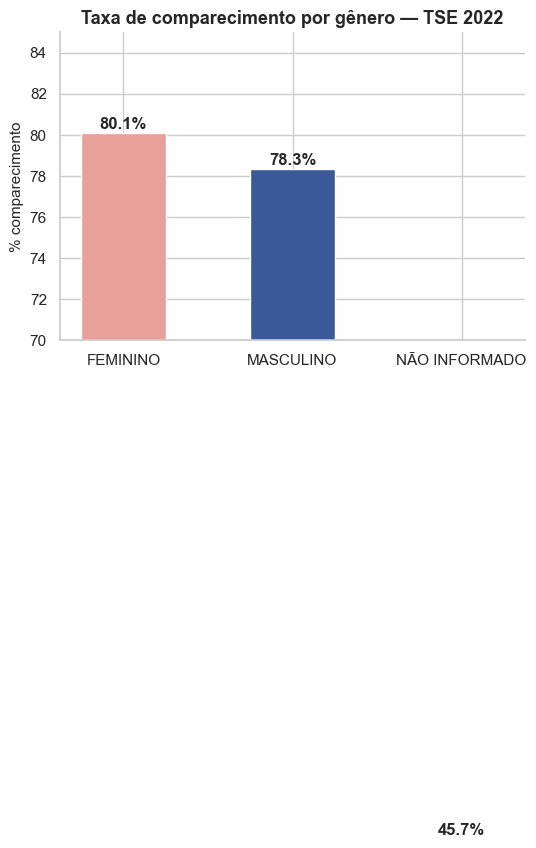

In [115]:
# Comparecimento por gênero — TSE.
df_gen = (df_tse_perfil
    .groupby("DS_GENERO", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"),
         QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum"))
    .reset_index()
)
df_gen["TAXA"] = df_gen["QT_COMPARECIMENTO"] / df_gen["QT_APTOS"] * 100

fig, ax = plt.subplots(figsize=(6, 4))
cores_gen = ["#e8a09a" if g == "FEMININO" else "#3b5998" for g in df_gen["DS_GENERO"]]
ax.bar(df_gen["DS_GENERO"], df_gen["TAXA"], color=cores_gen, width=0.5)
ax.set_title("Taxa de comparecimento por gênero — TSE 2022")
ax.set_ylabel("% comparecimento")
ax.set_ylim(70, 85)
for i, v in enumerate(df_gen["TAXA"]):
    ax.text(i, v + 0.2, f"{v:.1f}%", ha="center", fontweight="bold")
plt.tight_layout()
plt.show()


## 7. Cruzamento CESOP × TSE

**Núcleo do projeto.** A base CESOP mede percepção e disposição declarada; o TSE mede comportamento eleitoral real. Aqui investigamos se essas duas dimensões andam juntas.

Antes de cruzar, precisamos harmonizar nomenclaturas (região, escolaridade, faixa etária) entre as duas bases.


In [ ]:
# Funções de harmonização entre CESOP e TSE.
# As duas bases foram tratadas separadamente e usam convenções diferentes:
#   - REGIAO: CESOP 'NORDESTE' vs. TSE 'Nordeste'
#   - ESCOLARIDADE: CESOP em 5 grupos, TSE em 8 níveis
#   - FAIXA ETÁRIA: CESOP em faixas, TSE em idades individuais

REGIAO_CESOP_TO_TSE = {
    "NORTE": "Norte", "NORDESTE": "Nordeste",
    "SUDESTE": "Sudeste", "SUL": "Sul",
    "CENTRO OESTE": "Centro-Oeste",
}

ESCOL_TSE_TO_GRUPO = {
    "ANALFABETO": "Analfabeto",
    "LÊ E ESCREVE": "Sabe ler/escrever, mas não cursou escola",
    "ENSINO FUNDAMENTAL INCOMPLETO": "Até fundamental",
    "ENSINO FUNDAMENTAL COMPLETO": "Até fundamental",
    "ENSINO MÉDIO INCOMPLETO": "Médio",
    "ENSINO MÉDIO COMPLETO": "Médio",
    "SUPERIOR INCOMPLETO": "Superior",
    "SUPERIOR COMPLETO": "Superior",
}

def _fx_id_from_age(idade):
    """Bucketiza idade individual nas mesmas faixas do CESOP."""
    if pd.isna(idade):
        return np.nan
    if idade <= 17: return "16 E 17"
    if idade <= 24: return "18 A 24"
    if idade <= 34: return "25 A 34"
    if idade <= 44: return "35 A 44"
    if idade <= 54: return "45 A 54"
    if idade <= 64: return "55 A 64"
    return "65 E MAIS"

# Aplica as harmonizações em uma cópia da base TSE por perfil.
df_tse_h = df_tse_perfil.copy()
df_tse_h["IDADE_NUM"] = df_tse_h["DS_FAIXA_ETARIA"].map(_extract_age)
df_tse_h["ESCOL_GRUPO"] = df_tse_h["DS_GRAU_ESCOLARIDADE"].map(ESCOL_TSE_TO_GRUPO)
df_tse_h["FX_ID_CESOP"] = df_tse_h["IDADE_NUM"].map(_fx_id_from_age)

print("Harmonização aplicada. Amostra:")
df_tse_h[["DS_FAIXA_ETARIA", "FX_ID_CESOP", "DS_GRAU_ESCOLARIDADE", "ESCOL_GRUPO"]].head()


### 7.1 — Vontade declarada × comparecimento real, por região

Pergunta analítica: *regiões com menor vontade declarada de participar da política também apresentam menor comparecimento eleitoral?*


In [ ]:
# % de respondentes com "muita vontade" por região (CESOP).
ct_p4_reg = pd.crosstab(df_cesop["REGIAO"], df_cesop["P_04"], normalize="index") * 100
ct_p4_reg.index = ct_p4_reg.index.map(lambda x: REGIAO_CESOP_TO_TSE.get(str(x), str(x)))

# Identifica a coluna 'muita vontade' por substring (à prova de variação de label).
col_muita = [c for c in ct_p4_reg.columns if "muita" in str(c).lower()]
col_muita = col_muita[0] if col_muita else ct_p4_reg.columns[0]
vontade_por_regiao = ct_p4_reg[col_muita]

# Taxa de comparecimento TSE por região.
comparecimento_por_regiao = df_reg_tse.set_index("REGIAO")["TAXA_COMPARECIMENTO"]

df_cruz = pd.DataFrame({
    "Vontade ('muita' %)": vontade_por_regiao,
    "Comparecimento (%)": comparecimento_por_regiao,
}).dropna()

# Correlação de Spearman (pandas built-in, sem dependência de scipy).
rho = df_cruz.corr(method="spearman").iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 7))
for regiao, row in df_cruz.iterrows():
    cor = PALETA_REGIAO.get(regiao, "#999")
    ax.scatter(row["Vontade ('muita' %)"], row["Comparecimento (%)"],
               s=400, color=cor, edgecolors="black", linewidth=1.5, zorder=3)
    ax.annotate(regiao, (row["Vontade ('muita' %)"], row["Comparecimento (%)"]),
                textcoords="offset points", xytext=(12, 6), fontsize=12, fontweight="bold")

ax.set_xlabel('% com "muita vontade" de participar — CESOP')
ax.set_ylabel("Taxa de comparecimento eleitoral — TSE 2022 (%)")
ax.set_title(f"Vontade declarada × Comparecimento real — por região\nSpearman ρ = {rho:.2f}")
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "07_cruzamento_vontade_comparecimento.png", dpi=120, bbox_inches="tight")
plt.show()
print(df_cruz.round(2))


### 7.2 — Lembrança do voto × comparecimento, por região

Pergunta: regiões onde mais pessoas se lembram do voto também são as que mais comparecem nas urnas?


In [ ]:
# % que lembra do voto para deputado estadual, por região.
ct_lemb = pd.crosstab(df_cesop["REGIAO"], df_cesop["P_01A"], normalize="index") * 100
ct_lemb.index = ct_lemb.index.map(lambda x: REGIAO_CESOP_TO_TSE.get(str(x), str(x)))

df_cruz2 = pd.DataFrame({
    "Lembra do voto (%)": ct_lemb["Sim"],
    "Comparecimento (%)": comparecimento_por_regiao,
}).dropna()
rho2 = df_cruz2.corr(method="spearman").iloc[0, 1]

fig, ax = plt.subplots(figsize=(9, 7))
for regiao, row in df_cruz2.iterrows():
    cor = PALETA_REGIAO.get(regiao, "#999")
    ax.scatter(row["Lembra do voto (%)"], row["Comparecimento (%)"],
               s=400, color=cor, edgecolors="black", linewidth=1.5, zorder=3)
    ax.annotate(regiao, (row["Lembra do voto (%)"], row["Comparecimento (%)"]),
                textcoords="offset points", xytext=(12, 6), fontsize=12, fontweight="bold")

ax.set_xlabel("% que lembra do voto p/ deputado estadual — CESOP")
ax.set_ylabel("Taxa de comparecimento — TSE 2022 (%)")
ax.set_title(f"Lembrança × Comparecimento — por região\nSpearman ρ = {rho2:.2f}")
plt.tight_layout()
plt.show()
print(df_cruz2.round(2))


### 7.3 — A amostra CESOP é representativa do eleitorado?

Comparamos a composição da amostra CESOP com a composição do eleitorado brasileiro (TSE) em três dimensões: escolaridade, faixa etária e raça/cor.


In [ ]:
# Composição por escolaridade (5 grupos consolidados).
comp_cesop_e = df_cesop["ESCOL_GRUPO"].value_counts(normalize=True) * 100

tse_escol = (df_tse_h
    .dropna(subset=["ESCOL_GRUPO"])
    .groupby("ESCOL_GRUPO", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"))
)
tse_escol["pct"] = tse_escol["QT_APTOS"] / tse_escol["QT_APTOS"].sum() * 100
comp_tse_e = tse_escol["pct"]

ordem_e = ["Analfabeto", "Sabe ler/escrever, mas não cursou escola",
           "Até fundamental", "Médio", "Superior"]
df_comp_e = pd.DataFrame({"CESOP (amostra)": comp_cesop_e, "TSE (eleitorado)": comp_tse_e})
df_comp_e = df_comp_e.reindex(ordem_e).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
df_comp_e.plot.bar(ax=ax, color=[COR_PRINCIPAL, COR_SECUNDARIA], width=0.7)
ax.set_title("Composição por escolaridade — CESOP × Eleitorado TSE")
ax.set_ylabel("% do total")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=15)
ax.set_xticklabels([t.get_text()[:25] for t in ax.get_xticklabels()], ha="right")
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=2, fontsize=8)
plt.tight_layout()
plt.savefig(PATH_FIGURAS / "07_composicao_escolaridade.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# Composição por faixa etária.
comp_cesop_fx = df_cesop["FX_ID"].value_counts(normalize=True) * 100

tse_fx = (df_tse_h
    .dropna(subset=["FX_ID_CESOP"])
    .groupby("FX_ID_CESOP", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"))
)
tse_fx["pct"] = tse_fx["QT_APTOS"] / tse_fx["QT_APTOS"].sum() * 100
comp_tse_fx = tse_fx["pct"]

ordem_fx = ["16 E 17", "18 A 24", "25 A 34", "35 A 44", "45 A 54", "55 A 64", "65 E MAIS"]
df_comp_fx = pd.DataFrame({"CESOP (amostra)": comp_cesop_fx, "TSE (eleitorado)": comp_tse_fx})
df_comp_fx = df_comp_fx.reindex(ordem_fx).fillna(0)

fig, ax = plt.subplots(figsize=(12, 6))
df_comp_fx.plot.bar(ax=ax, color=[COR_PRINCIPAL, COR_SECUNDARIA], width=0.7)
ax.set_title("Composição por faixa etária — CESOP × Eleitorado TSE")
ax.set_ylabel("% do total")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=0)
for c in ax.containers:
    ax.bar_label(c, fmt="%.1f%%", padding=2, fontsize=8)
plt.tight_layout()
plt.show()


### 7.4 — Gradiente educacional: vontade × comparecimento

Comparamos, no mesmo gráfico, a **vontade média declarada** (CESOP, escala 1-3) e a **taxa de comparecimento real** (TSE) por nível de escolaridade. Se ambos crescem juntos, há evidência de coerência entre o que se declara e o que se faz.


In [ ]:
# Mapeia P_04 para escala ordinal 1-3 (nenhuma=1, alguma=2, muita=3).
def _map_p4_num(v):
    if pd.isna(v):
        return np.nan
    s = str(v).lower()
    if "muita" in s: return 3
    if "alguma" in s: return 2
    if "nenhuma" in s: return 1
    return np.nan

df_aux = df_cesop.assign(P_04_NUM=df_cesop["P_04"].map(_map_p4_num))
vontade_por_escol = df_aux.groupby("ESCOL_GRUPO", observed=True)["P_04_NUM"].mean()

# Comparecimento por ESCOL_GRUPO consolidado (TSE).
tse_escol_taxa = (df_tse_h
    .dropna(subset=["ESCOL_GRUPO"])
    .groupby("ESCOL_GRUPO", observed=True)
    .agg(QT_APTOS=("QT_APTOS", "sum"),
         QT_COMPARECIMENTO=("QT_COMPARECIMENTO", "sum"))
)
tse_escol_taxa["TAXA"] = tse_escol_taxa["QT_COMPARECIMENTO"] / tse_escol_taxa["QT_APTOS"] * 100

df_grad = pd.DataFrame({
    "Vontade média (CESOP)": vontade_por_escol.reindex(ordem_e),
    "Comparecimento (%) TSE": tse_escol_taxa["TAXA"].reindex(ordem_e),
})

# Gráfico de duplo eixo: escalas diferentes, mas tendência comparável.
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()
x = np.arange(len(df_grad))
w = 0.35

b1 = ax1.bar(x - w / 2, df_grad["Vontade média (CESOP)"], w,
             color=COR_PRINCIPAL, label="Vontade média (CESOP, 1-3)")
b2 = ax2.bar(x + w / 2, df_grad["Comparecimento (%) TSE"], w,
             color=COR_SECUNDARIA, label="Comparecimento (TSE %)")

ax1.set_xticks(x)
ax1.set_xticklabels([s[:20] for s in df_grad.index], rotation=15, ha="right")
ax1.set_ylabel("Vontade média (1=nenhuma, 3=muita)")
ax2.set_ylabel("% comparecimento eleitoral")
ax1.set_ylim(1, 3)
ax2.set_ylim(60, 90)
ax1.set_title("Gradiente educacional: vontade declarada × comparecimento real")

# Combina legendas dos dois eixos.
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.savefig(PATH_FIGURAS / "07_gradiente_educacional.png", dpi=120, bbox_inches="tight")
plt.show()
print(df_grad.round(2))


## 8. Síntese e próximos passos

### Principais achados (preencher após executar)

- **Perfil CESOP:** ...
- **Lembrança do voto:** ...
- **Prioridades políticas:** ...
- **Fake news:** ...
- **Vontade de participar (P.04):** ...
- **Panorama TSE:** ...
- **Cruzamento principal (vontade × comparecimento):** ...
- **Representatividade da amostra:** ...

### Hipóteses para o notebook 03

1. Existe associação estatisticamente significativa entre escolaridade e vontade de participar? (teste qui-quadrado)
2. A correlação regional entre vontade declarada e comparecimento real se sustenta no nível municipal?
3. O perfil de respondentes que "não lembra" do voto difere sistematicamente do perfil de quem lembra?
4. As prioridades políticas mudam significativamente com renda? (heatmap + teste)

### Artefatos gerados

Figuras-chave salvas em `reports/imagens/`:
- `01_perfil_cesop.png`
- `05_vontade_dimensoes.png`
- `06_tse_ranking_ufs.png`
- `07_cruzamento_vontade_comparecimento.png`
- `07_composicao_escolaridade.png`
- `07_gradiente_educacional.png`
